# Dual Si(Li) `22Na` Spectrum Analysis

Analyze the multithreaded Geant4 output table for the dual-sided Si(Li) positron spectrometer with three HPGe detectors.

This notebook expects the default Parquet file at `output/dual_sili_22na.parquet` and produces spectra, coincidence plots, symmetry checks, and peak/edge fits.

## Plan

- Load the event-by-event Parquet table and summarize nonzero detector rates.
- Plot Si(Li) single-detector and summed spectra, including symmetry comparisons.
- Plot HPGe individual and combined spectra.
- Fit the 511 keV and 1274.5 keV HPGe full-energy peaks with a Gaussian plus linear background.
- Estimate HPGe Compton edges with a smeared-step model.
- Plot Si(Li)-HPGe coincidence and gated spectra.
- Add a triple full-energy HPGe tag: two 511 keV annihilation photons plus the 1274.5 keV gamma.

All plots are Matplotlib figures. The helper `savefig` displays them inline in Jupyter and also writes PNG copies to `output/notebook_figures/`.

If the Parquet file contains an `event_weight` column from importance sampling, this notebook uses it automatically for histograms, 2D maps, gate summaries, and spectrum fits. Raw event counts are still shown where useful as a diagnostic.


In [55]:
from __future__ import annotations

import os
from pathlib import Path
import warnings

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
os.environ.setdefault("XDG_CACHE_HOME", "/tmp")

import numpy as np
import polars as pl
import matplotlib
try:
    IN_NOTEBOOK = "IPKernelApp" in get_ipython().config
except Exception:
    IN_NOTEBOOK = False

if IN_NOTEBOOK:
    try:
        get_ipython().run_line_magic("matplotlib", "inline")
    except Exception:
        pass
else:
    matplotlib.use("Agg")

import matplotlib.pyplot as plt
from IPython.display import display
from scipy.optimize import curve_fit
from scipy.special import erfc

warnings.filterwarnings("ignore", category=RuntimeWarning)

plt.rcParams.update({
    "figure.figsize": (9, 5),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

In [56]:
# Configuration
NOTEBOOK_PATH = Path.cwd()
REPO_ROOT = NOTEBOOK_PATH
if not (REPO_ROOT / "output").exists():
    # Common when running from analysis/notebooks in Jupyter.
    REPO_ROOT = NOTEBOOK_PATH.parents[1]

DATA_PATH = REPO_ROOT / "output" / "dual_sili_22na_50000000.parquet"
#DATA_PATH = "../../build/output/dual_sili_22na_importance_hpge_triple.parquet"
FIG_DIR = REPO_ROOT / "output" / "notebook_figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

SOURCE_TIME_NS = 1.0e20 * 1.0e9
HPGE_COLUMNS = ["E_HPGe_1_keV", "E_HPGe_2_keV", "E_HPGe_3_keV"]
SILI_COLUMNS = ["E_SiLi_1_keV", "E_SiLi_2_keV"]

EXPECTED = {
    "annihilation_keV": 511.0,
    "na22_gamma_keV": 1274.5,
}
EXPECTED["compton_511_keV"] = EXPECTED["annihilation_keV"] * (1 - 1 / (1 + 2 * EXPECTED["annihilation_keV"] / 511.0))
EXPECTED["compton_1274_keV"] = EXPECTED["na22_gamma_keV"] * (1 - 1 / (1 + 2 * EXPECTED["na22_gamma_keV"] / 511.0))

print(f"Reading: {DATA_PATH}")
print(f"Figures: {FIG_DIR}")
print(EXPECTED)

Reading: /Users/ronguy/Code/BpSpec/DualSiLi22Na/output/dual_sili_22na_50000000.parquet
Figures: /Users/ronguy/Code/BpSpec/DualSiLi22Na/output/notebook_figures
{'annihilation_keV': 511.0, 'na22_gamma_keV': 1274.5, 'compton_511_keV': 340.6666666666667, 'compton_1274_keV': 1061.6668300653596}


## Load And Sanity Check

Each row is one simulated event. Energies are raw deposited energies in the active detector volumes; no electronic resolution smearing is applied.

In [57]:
scan = pl.scan_parquet(DATA_PATH)
available_columns = set(scan.collect_schema().names())
analysis_columns = [
    "eventID",
    "event_weight",
    *SILI_COLUMNS,
    "E_SiLi_sum_keV",
    *HPGE_COLUMNS,
    "E_total_all_detectors_keV",
    "Nhit_SiLi_1",
    "Nhit_SiLi_2",
    "Nhit_HPGe_1",
    "Nhit_HPGe_2",
    "Nhit_HPGe_3",
    "tfirst_SiLi_1_ns",
    "tfirst_SiLi_2_ns",
    "tfirst_HPGe_1_ns",
    "tfirst_HPGe_2_ns",
    "tfirst_HPGe_3_ns",
    "primary_beta_kinetic_keV",
]
selected_columns = [name for name in analysis_columns if name in available_columns]
df = scan.select(selected_columns).collect()
print(f"rows={df.height:,}, columns={df.width}")
display(df.head())


def column_array(name, dtype=float):
    array = df.get_column(name).to_numpy()
    if dtype is None:
        return array
    return array.astype(dtype, copy=False)


def select_matrix(names):
    return df.select(names).to_numpy()


def sum_columns(names):
    return df.select(pl.sum_horizontal([pl.col(name) for name in names]).alias("sum")).to_series().to_numpy()


def max_columns(names):
    return df.select(pl.max_horizontal([pl.col(name) for name in names]).alias("max")).to_series().to_numpy()


HAS_WEIGHTS = "event_weight" in df.columns
if HAS_WEIGHTS:
    event_weight = column_array("event_weight")
    event_weight = np.where(np.isfinite(event_weight), event_weight, 0.0)
else:
    event_weight = np.ones(df.height, dtype=float)

COUNT_LABEL = "Weighted events" if HAS_WEIGHTS else "Events"
COUNT_LABEL_LOWER = "weighted events" if HAS_WEIGHTS else "events"
BIN_LABEL_SUFFIX = "weighted events / bin" if HAS_WEIGHTS else "events / bin"

HAS_BETA_TRUTH = "primary_beta_kinetic_keV" in df.columns and bool(
    df.select((pl.col("primary_beta_kinetic_keV") >= 0).any()).item()
)
if HAS_BETA_TRUTH:
    beta_truth_keV = column_array("primary_beta_kinetic_keV")
else:
    beta_truth_keV = np.full(df.height, np.nan)


def weighted_count(mask):
    mask = np.asarray(mask, dtype=bool)
    return float(event_weight[mask].sum())


def effective_entries(weights):
    weights = np.asarray(weights, dtype=float)
    sumw = weights.sum()
    sumw2 = np.square(weights).sum()
    return float(sumw * sumw / sumw2) if sumw2 > 0 else 0.0


def metrics_frame(mapping, key_name="metric", value_name="value"):
    return pl.DataFrame(
        {key_name: list(mapping.keys()), value_name: list(mapping.values())},
        strict=False,
    )


print("event weights:", "enabled" if HAS_WEIGHTS else "not present; using unit weights")
print("generated beta kinetic energy:", "available" if HAS_BETA_TRUTH else "not available")
if HAS_WEIGHTS:
    display(metrics_frame({
        "sum_event_weight": event_weight.sum(),
        "min_event_weight": event_weight.min(),
        "max_event_weight": event_weight.max(),
        "effective_entries": effective_entries(event_weight),
    }))

sili_sum_for_summary = column_array("E_SiLi_sum_keV")
hpge_sum_for_summary = sum_columns(HPGE_COLUMNS)
summary_masks = {
    "events": np.ones(df.height, dtype=bool),
    "events with nonzero Si(Li)": sili_sum_for_summary > 0,
    "events with nonzero HPGe": hpge_sum_for_summary > 0,
    "events with both Si(Li) and HPGe": (sili_sum_for_summary > 0) & (hpge_sum_for_summary > 0),
}
event_summary = pl.DataFrame({
    "quantity": list(summary_masks),
    "raw_count": [int(mask.sum()) for mask in summary_masks.values()],
    "weighted_count": [weighted_count(mask) for mask in summary_masks.values()],
}).with_columns(
    raw_fraction=pl.col("raw_count") / df.height,
    weighted_fraction=pl.col("weighted_count") / float(event_weight.sum()),
)
display(event_summary)

display(df.select(SILI_COLUMNS + ["E_SiLi_sum_keV"] + HPGE_COLUMNS).describe())

rows=100,000,000, columns=20


eventID,event_weight,E_SiLi_1_keV,E_SiLi_2_keV,E_SiLi_sum_keV,E_HPGe_1_keV,E_HPGe_2_keV,E_HPGe_3_keV,E_total_all_detectors_keV,Nhit_SiLi_1,Nhit_SiLi_2,Nhit_HPGe_1,Nhit_HPGe_2,Nhit_HPGe_3,tfirst_SiLi_1_ns,tfirst_SiLi_2_ns,tfirst_HPGe_1_ns,tfirst_HPGe_2_ns,tfirst_HPGe_3_ns,primary_beta_kinetic_keV
i64,i64,f64,f64,f64,f64,f64,f64,f64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,i64
26520,1,0.0,246.28565,246.28565,0.0,0.0,0.0,246.28565,0,12,0,0,0,-1.0,1.0000e29,-1.0,-1.0,-1.0,-1000
26521,1,335.97971,0.0,335.97971,0.0,174.41989,0.0,510.3996,11,0,0,1,0,1.0000e29,-1.0,-1.0,1.0000e29,-1.0,-1000
26522,1,135.53124,0.0,135.53124,0.0,0.0,0.0,135.53124,12,0,0,0,0,1.0000e29,-1.0,-1.0,-1.0,-1.0,-1000
26523,1,30.824001,285.79666,316.62066,0.0,0.0,49.77297,366.39363,6,10,0,0,1,1.0000e29,1.0000e29,-1.0,-1.0,1.0000e29,-1000
26524,1,100.7943,0.0,100.7943,0.0,0.0,0.0,100.7943,10,0,0,0,0,1.0000e29,-1.0,-1.0,-1.0,-1.0,-1000


event weights: enabled
generated beta kinetic energy: not available


metric,value
str,f64
"""sum_event_weight""",1e8
"""min_event_weight""",1.0
"""max_event_weight""",1.0
"""effective_entries""",1e8


quantity,raw_count,weighted_count,raw_fraction,weighted_fraction
str,i64,f64,f64,f64
"""events""",100000000,1e8,1.0,1.0
"""events with nonzero Si(Li)""",87702649,8.7702649e7,0.877026,0.877026
"""events with nonzero HPGe""",44313403,4.4313403e7,0.443134,0.443134
"""events with both Si(Li) and HP…",41109056,4.1109056e7,0.411091,0.411091


statistic,E_SiLi_1_keV,E_SiLi_2_keV,E_SiLi_sum_keV,E_HPGe_1_keV,E_HPGe_2_keV,E_HPGe_3_keV
str,f64,f64,f64,f64,f64,f64
"""count""",1e8,1e8,1e8,1e8,1e8,1e8
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",146.328023,146.388734,292.716757,83.552696,83.592886,84.594319
"""std""",214.593312,214.708716,284.975653,232.560125,232.613842,233.062383
"""min""",0.0,0.0,0.0,0.0,0.0,0.0
"""25%""",0.0,0.0,92.955041,0.0,0.0,0.0
"""50%""",55.153258,55.18434,231.91277,0.0,0.0,0.0
"""75%""",225.84035,225.90058,393.31861,0.0,0.0,0.0
"""max""",2434.4343,2413.5341,2547.661,2339.495,2275.9093,2310.7066


In [58]:
def finite_positive_mask(values, threshold=0.0):
    values = np.asarray(values, dtype=float)
    return np.isfinite(values) & (values > threshold)


def finite_positive(values, threshold=0.0):
    values = np.asarray(values, dtype=float)
    return values[finite_positive_mask(values, threshold)]


def weights_for_mask(mask):
    mask = np.asarray(mask, dtype=bool)
    return event_weight[mask] if HAS_WEIGHTS else None


def finite_positive_with_weights(values, threshold=0.0, base_weights=None):
    values = np.asarray(values, dtype=float)
    mask = finite_positive_mask(values, threshold)
    selected_values = values[mask]
    if base_weights is None:
        selected_weights = event_weight[mask] if HAS_WEIGHTS else None
    else:
        base_weights = np.asarray(base_weights, dtype=float)
        selected_weights = base_weights[mask]
    return selected_values, selected_weights


def hist_counts(values, bins, weights=None, return_variance=False):
    values = np.asarray(values, dtype=float)
    if weights is not None:
        weights = np.asarray(weights, dtype=float)
    counts, edges = np.histogram(values, bins=bins, weights=weights)
    centers = 0.5 * (edges[:-1] + edges[1:])
    widths = np.diff(edges)
    if return_variance:
        if weights is None:
            variances = counts.astype(float)
        else:
            variances, _ = np.histogram(values, bins=bins, weights=np.square(weights))
        return counts.astype(float), centers, widths, variances.astype(float)
    return counts.astype(float), centers, widths


def hist_sigma(variances, weighted=None):
    variances = np.asarray(variances, dtype=float)
    if weighted is None:
        weighted = HAS_WEIGHTS
    positive = variances[variances > 0]
    floor = float(np.median(positive)) if weighted and len(positive) else 1.0
    return np.sqrt(np.maximum(variances, floor))


def step_hist(ax, values, bins, label=None, weights=None, **kwargs):
    counts, edges = np.histogram(values, bins=bins, weights=weights)
    ax.stairs(counts, edges, label=label, **kwargs)
    return counts, edges


def weighted_mean(values, weights=None):
    values = np.asarray(values, dtype=float)
    if weights is None:
        return float(np.nanmean(values))
    mask = np.isfinite(values) & np.isfinite(weights) & (weights > 0)
    return float(np.average(values[mask], weights=weights[mask])) if mask.any() else np.nan


def savefig(fig, name):
    out = FIG_DIR / name
    fig.tight_layout()
    fig.savefig(out, dpi=180)
    display(fig)
    if not IN_NOTEBOOK:
        plt.close(fig)
    try:
        shown = out.relative_to(REPO_ROOT)
    except ValueError:
        shown = out
    print(f"saved {shown}")


def gaussian_linear(x, amp, mu, sigma, slope, intercept):
    return amp * np.exp(-0.5 * ((x - mu) / sigma) ** 2) + slope * x + intercept


def smooth_1d_counts(counts, sigma_bins=1.5):
    counts = np.asarray(counts, dtype=float)
    sigma_bins = float(sigma_bins)
    if counts.size == 0 or sigma_bins <= 0:
        return counts.copy()
    radius = max(1, int(np.ceil(4.0 * sigma_bins)))
    offsets = np.arange(-radius, radius + 1, dtype=float)
    kernel = np.exp(-0.5 * (offsets / sigma_bins) ** 2)
    kernel /= kernel.sum()
    padded = np.pad(counts, radius, mode="edge")
    return np.convolve(padded, kernel, mode="same")[radius:-radius]


def smeared_edge(x, baseline, amplitude, edge, sigma, slope):
    # Falling Compton edge: baseline above the edge plus a positive step below it.
    return baseline + 0.5 * amplitude * erfc((x - edge) / (np.sqrt(2) * sigma)) + slope * (x - edge)


def fit_edge(values, expected, window=80.0, bin_width=2.0, label="edge", weights=None, edge_tolerance=None):
    values, fit_weights = finite_positive_with_weights(values, threshold=0.0, base_weights=weights)
    lo, hi = expected - window, expected + window
    bins = np.arange(lo, hi + bin_width, bin_width)
    counts, centers, _, variances = hist_counts(values, bins, weights=fit_weights, return_variance=True)
    finite = np.isfinite(counts) & np.isfinite(variances)
    nonzero = counts > 0
    if np.count_nonzero(nonzero) < 10 or counts.sum() < 40:
        return {"label": label, "ok": False, "reason": "too few counts", "expected_keV": expected, "bins": bins}

    smooth_counts = smooth_1d_counts(counts, sigma_bins=max(1.0, 6.0 / bin_width))
    gradient = np.gradient(smooth_counts, centers)
    if edge_tolerance is None:
        edge_tolerance = min(0.35 * window, 45.0)
    edge_lo = expected - edge_tolerance
    edge_hi = expected + edge_tolerance
    edge_region = (centers >= edge_lo) & (centers <= edge_hi) & np.isfinite(gradient)
    if np.any(edge_region):
        edge_seed = centers[edge_region][int(np.argmin(gradient[edge_region]))]
    else:
        edge_seed = expected

    below = smooth_counts[(centers < expected - 0.15 * window) & finite]
    above = smooth_counts[(centers > expected + 0.15 * window) & finite]
    baseline0 = float(np.median(above)) if above.size else float(np.percentile(smooth_counts[finite], 25))
    high0 = float(np.median(below)) if below.size else float(np.percentile(smooth_counts[finite], 75))
    amplitude0 = max(high0 - baseline0, 0.1 * max(float(np.nanmax(smooth_counts)), 1.0))
    dynamic = max(float(np.nanpercentile(smooth_counts[finite], 95) - np.nanpercentile(smooth_counts[finite], 5)), 1.0)
    slope_limit = max(2.0 * dynamic / window, 1.0 / max(bin_width, 1.0))

    fit_mask = finite
    x = centers[fit_mask]
    y = counts[fit_mask]
    sigma_y = hist_sigma(variances[fit_mask], weighted=fit_weights is not None)
    p0 = [max(baseline0, 0.0), amplitude0, edge_seed, max(1.5 * bin_width, 4.0), 0.0]
    bounds = (
        [0.0, 0.0, edge_lo, 0.5 * bin_width, -slope_limit],
        [np.inf, np.inf, edge_hi, 0.35 * window, slope_limit],
    )
    try:
        popt, pcov = curve_fit(
            smeared_edge,
            x,
            y,
            p0=p0,
            sigma=sigma_y,
            absolute_sigma=True,
            bounds=bounds,
            maxfev=30000,
        )
        perr = np.sqrt(np.diag(pcov))
    except Exception as exc:
        return {
            "label": label,
            "ok": False,
            "reason": str(exc),
            "expected_keV": expected,
            "bins": bins,
            "edge_seed_keV": edge_seed,
        }

    residual = (y - smeared_edge(x, *popt)) / sigma_y
    ndof = len(y) - len(popt)
    return {
        "label": label,
        "ok": True,
        "expected_keV": expected,
        "edge_keV": popt[2],
        "edge_err_keV": perr[2],
        "edge_seed_keV": edge_seed,
        "edge_fit_lo_keV": edge_lo,
        "edge_fit_hi_keV": edge_hi,
        "sigma_keV": abs(popt[3]),
        "chi2_ndof": float(np.sum(residual ** 2)) / ndof if ndof > 0 else np.nan,
        "popt": popt,
        "pcov": pcov,
        "x": x,
        "y": y,
        "bins": bins,
        "variances": variances,
        "smooth_counts": smooth_counts,
        "centers": centers,
    }


def fit_peak(values, expected, window=25.0, bin_width=1.0, label="peak", weights=None):
    values, fit_weights = finite_positive_with_weights(values, threshold=0.0, base_weights=weights)
    lo, hi = expected - window, expected + window
    bins = np.arange(lo, hi + bin_width, bin_width)
    counts, centers, _, variances = hist_counts(values, bins, weights=fit_weights, return_variance=True)
    if counts.sum() < 10 or np.count_nonzero(counts) < 1:
        return {"label": label, "ok": False, "reason": "too few counts", "expected_keV": expected}

    # Keep zero-count side bins. They stabilize fits to very narrow unsmeared peaks.
    x = centers
    y = counts
    sigma_y = hist_sigma(variances, weighted=fit_weights is not None)
    local_bg = np.percentile(y, 20)
    p0 = [max(y.max() - local_bg, 1.0), centers[np.argmax(y)], 0.6, 0.0, max(local_bg, 0.0)]
    bounds = ([0.0, lo, 0.03, -np.inf, -np.inf], [np.inf, hi, window, np.inf, np.inf])
    try:
        popt, pcov = curve_fit(
            gaussian_linear, x, y, p0=p0, sigma=sigma_y,
            absolute_sigma=True, bounds=bounds, maxfev=50000
        )
        perr = np.sqrt(np.diag(pcov))
    except Exception as exc:
        return {"label": label, "ok": False, "reason": str(exc), "expected_keV": expected}

    amp, mu, sigma, slope, intercept = popt
    fwhm = 2.354820045 * abs(sigma)
    area = amp * abs(sigma) * np.sqrt(2 * np.pi) / bin_width
    return {
        "label": label, "ok": True, "expected_keV": expected,
        "mu_keV": mu, "mu_err_keV": perr[1],
        "sigma_keV": abs(sigma), "sigma_err_keV": perr[2],
        "fwhm_keV": fwhm, "area_counts": area,
        "popt": popt, "pcov": pcov, "x": x, "y": y, "bins": bins,
        "variances": variances,
    }

## Si(Li) Spectra And Symmetry

The two Si(Li) detectors should agree statistically. The summed spectrum is the quantity most useful for recovering split-energy/backscatter events.

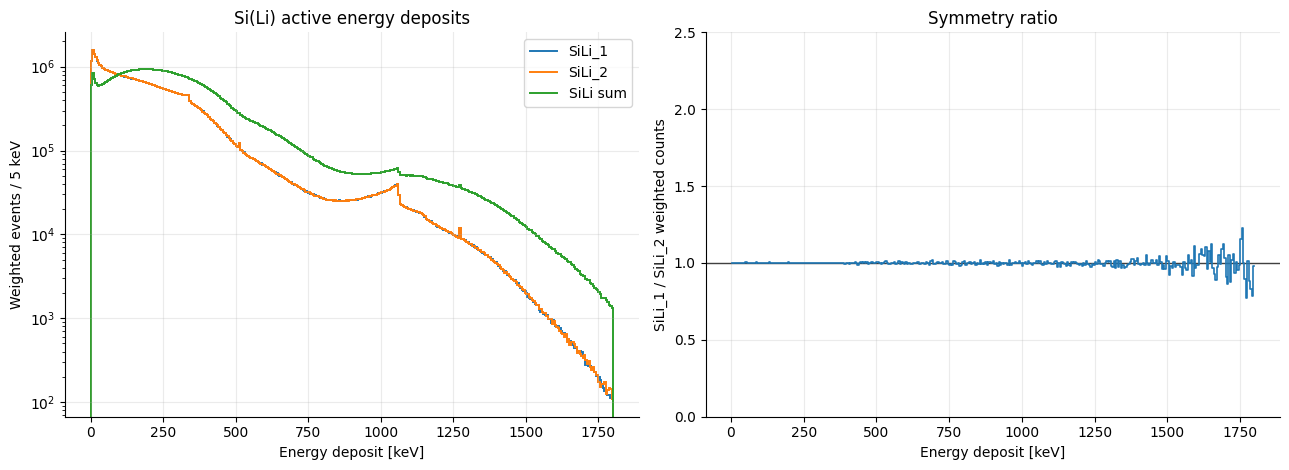

saved output/notebook_figures/sili_spectra_symmetry.png


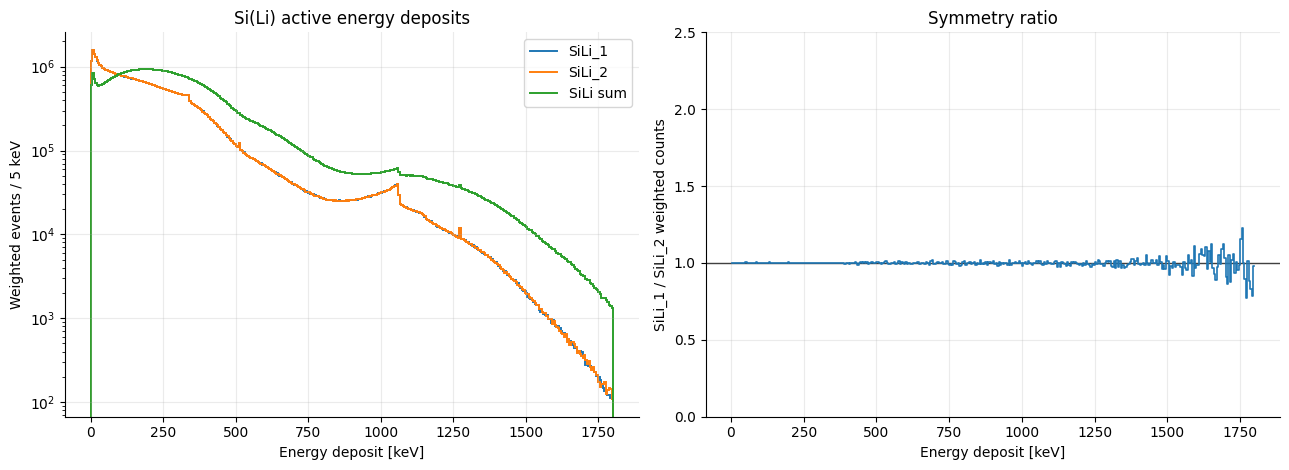

In [59]:
sili1 = column_array("E_SiLi_1_keV")
sili2 = column_array("E_SiLi_2_keV")
silisum = column_array("E_SiLi_sum_keV")

bins_sili = np.linspace(0, 1800, 361)
sili1_pos, sili1_w = finite_positive_with_weights(sili1)
sili2_pos, sili2_w = finite_positive_with_weights(sili2)
silisum_pos, silisum_w = finite_positive_with_weights(silisum)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
step_hist(axes[0], sili1_pos, bins_sili, weights=sili1_w, label="SiLi_1", linewidth=1.4)
step_hist(axes[0], sili2_pos, bins_sili, weights=sili2_w, label="SiLi_2", linewidth=1.4)
step_hist(axes[0], silisum_pos, bins_sili, weights=silisum_w, label="SiLi sum", linewidth=1.4)
axes[0].set_xlabel("Energy deposit [keV]")
axes[0].set_ylabel(f"{COUNT_LABEL} / 5 keV")
axes[0].set_yscale("log")
axes[0].legend()
axes[0].set_title("Si(Li) active energy deposits")

c1, edges = np.histogram(sili1_pos, bins=bins_sili, weights=sili1_w)
c2, _ = np.histogram(sili2_pos, bins=bins_sili, weights=sili2_w)
centers = 0.5 * (edges[:-1] + edges[1:])
ratio = np.divide(c1, c2, out=np.full_like(c1, np.nan, dtype=float), where=c2 > 0)
axes[1].axhline(1.0, color="0.25", linewidth=1)
axes[1].plot(centers, ratio, drawstyle="steps-mid", linewidth=1.2)
axes[1].set_ylim(0, 2.5)
axes[1].set_xlabel("Energy deposit [keV]")
axes[1].set_ylabel("SiLi_1 / SiLi_2 weighted counts" if HAS_WEIGHTS else "SiLi_1 / SiLi_2 counts")
axes[1].set_title("Symmetry ratio")
savefig(fig, "sili_spectra_symmetry.png")

In [60]:
# Quantify symmetry with simple per-event and binned metrics.
nonzero_either = (sili1 > 0) | (sili2 > 0)
symmetry_metrics = {
    "mean_E_SiLi_1_keV": weighted_mean(sili1, event_weight if HAS_WEIGHTS else None),
    "mean_E_SiLi_2_keV": weighted_mean(sili2, event_weight if HAS_WEIGHTS else None),
    "mean_difference_keV": weighted_mean(sili1 - sili2, event_weight if HAS_WEIGHTS else None),
    "median_abs_difference_when_hit_keV_raw": float(np.median(np.abs(sili1[nonzero_either] - sili2[nonzero_either]))),
    "events_split_between_both_SiLi_raw": int(((sili1 > 0) & (sili2 > 0)).sum()),
    "events_only_SiLi_1_raw": int(((sili1 > 0) & (sili2 <= 0)).sum()),
    "events_only_SiLi_2_raw": int(((sili2 > 0) & (sili1 <= 0)).sum()),
    "events_split_between_both_SiLi_weighted": weighted_count((sili1 > 0) & (sili2 > 0)),
    "events_only_SiLi_1_weighted": weighted_count((sili1 > 0) & (sili2 <= 0)),
    "events_only_SiLi_2_weighted": weighted_count((sili2 > 0) & (sili1 <= 0)),
}
display(metrics_frame(symmetry_metrics))

metric,value
str,f64
"""mean_E_SiLi_1_keV""",146.328023
"""mean_E_SiLi_2_keV""",146.388734
"""mean_difference_keV""",-0.060712
"""median_abs_difference_when_hit…",193.13705
"""events_split_between_both_SiLi…",3.7717452e7
"""events_only_SiLi_1_raw""",2.4989439e7
"""events_only_SiLi_2_raw""",2.4995758e7
"""events_split_between_both_SiLi…",3.7717452e7
"""events_only_SiLi_1_weighted""",2.4989439e7


## Si(Li) Energy Sharing

This 2D view highlights events where positron energy is split between both detectors. Diagonal structure corresponds to approximately conserved summed deposited energy.

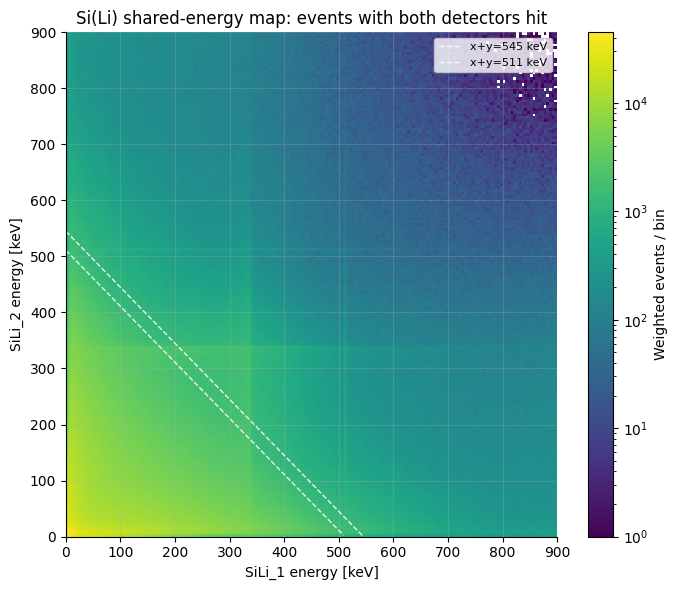

saved output/notebook_figures/sili_energy_sharing_2d.png


metric,events
str,f64
"""events with SiLi_1 > 0.1 keV r…",6.2702706e7
"""events with SiLi_2 > 0.1 keV r…",6.2709007e7
"""events with both Si(Li) detect…",3.7710902e7
"""events with SiLi_1 > 0.1 keV w…",6.2702706e7
"""events with SiLi_2 > 0.1 keV w…",6.2709007e7
"""events with both Si(Li) detect…",3.7710902e7


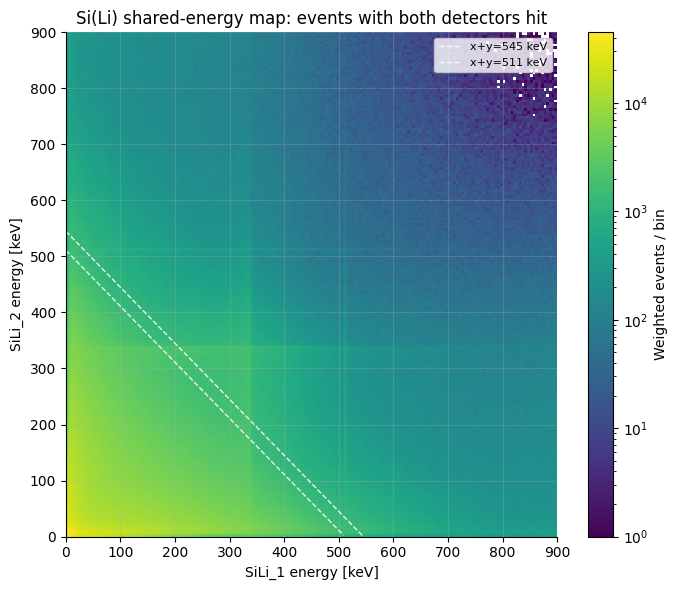

In [61]:
from matplotlib.colors import LogNorm

split_mask = (
    np.isfinite(sili1)
    & np.isfinite(sili2)
    & (sili1 > 0.1)
    & (sili2 > 0.1)
)

fig, ax = plt.subplots(figsize=(7, 6))
h = ax.hist2d(
    sili1[split_mask],
    sili2[split_mask],
    bins=180,
    range=[[0, 900], [0, 900]],
    weights=weights_for_mask(split_mask),
    cmap="viridis",
    norm=LogNorm(),
    cmin=None if HAS_WEIGHTS else 1,
)
fig.colorbar(h[3], ax=ax, label=f"{COUNT_LABEL} / bin")

x = np.linspace(0, 900, 300)
for total, label in [(545.0, "x+y=545 keV"), (EXPECTED["annihilation_keV"], "x+y=511 keV")]:
    y = total - x
    visible = (y >= 0) & (y <= 900)
    ax.plot(x[visible], y[visible], color="white", linewidth=1.0, linestyle="--", alpha=0.85, label=label)

ax.set_xlabel("SiLi_1 energy [keV]")
ax.set_ylabel("SiLi_2 energy [keV]")
ax.set_title("Si(Li) shared-energy map: events with both detectors hit")
ax.legend(fontsize=8, loc="upper right")
savefig(fig, "sili_energy_sharing_2d.png")

split_counts = metrics_frame({
    "events with SiLi_1 > 0.1 keV raw": int((sili1 > 0.1).sum()),
    "events with SiLi_2 > 0.1 keV raw": int((sili2 > 0.1).sum()),
    "events with both Si(Li) detectors > 0.1 keV raw": int(split_mask.sum()),
    "events with SiLi_1 > 0.1 keV weighted": weighted_count(sili1 > 0.1),
    "events with SiLi_2 > 0.1 keV weighted": weighted_count(sili2 > 0.1),
    "events with both Si(Li) detectors > 0.1 keV weighted": weighted_count(split_mask),
})
display(split_counts.rename({"value": "events"}))

## HPGe Spectra

The individual HPGe spectra test the `+X`, `-X`, and `+Y` detector response. The combined spectrum gives higher statistics for fitting the 511 keV annihilation line and the 1274.5 keV gamma.

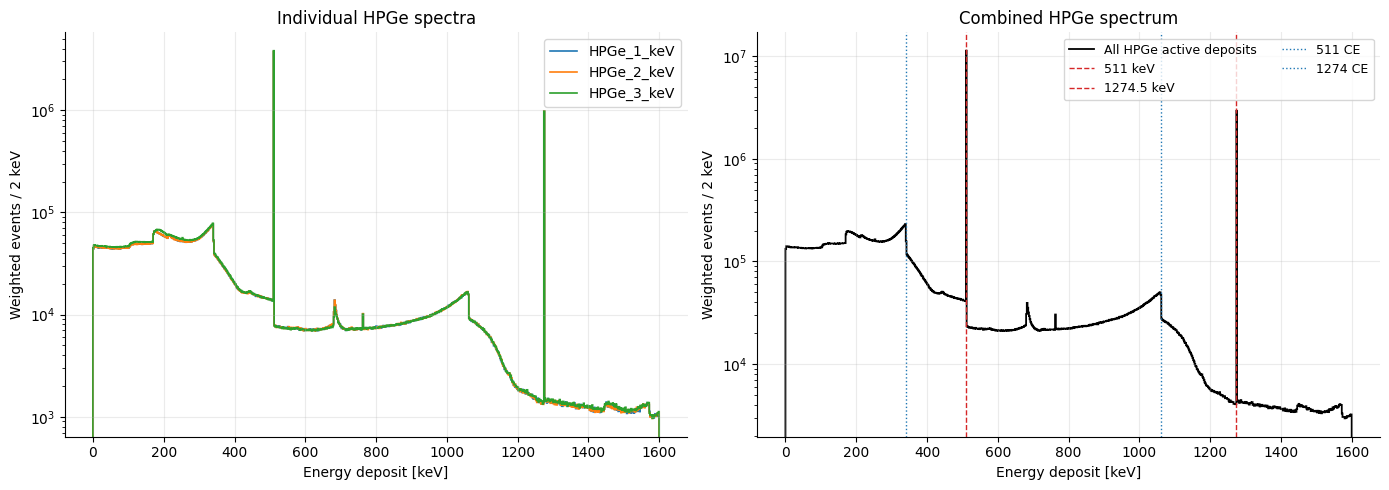

saved output/notebook_figures/hpge_spectra.png


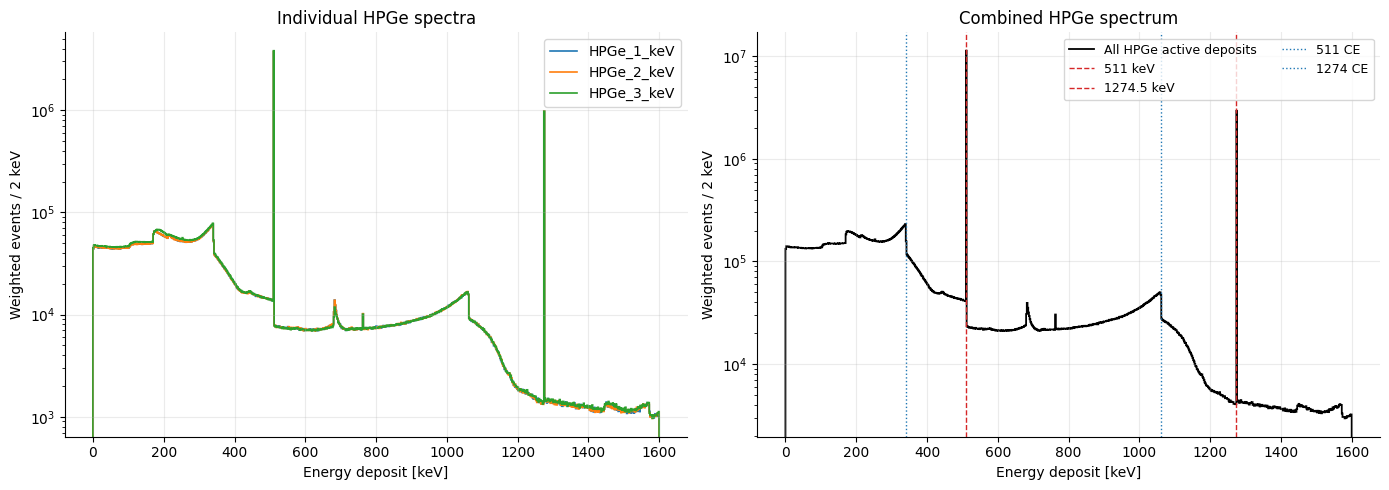

In [62]:
hpge = {name: column_array(name) for name in HPGE_COLUMNS}
hpge_all_parts = []
hpge_all_weight_parts = []
for values in hpge.values():
    vals, wts = finite_positive_with_weights(values, threshold=0.1)
    hpge_all_parts.append(vals)
    if wts is not None:
        hpge_all_weight_parts.append(wts)

hpge_all = np.concatenate(hpge_all_parts) if hpge_all_parts else np.array([])
hpge_all_weights = np.concatenate(hpge_all_weight_parts) if hpge_all_weight_parts else None

bins_hpge = np.linspace(0, 1600, 801)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for col, values in hpge.items():
    vals, wts = finite_positive_with_weights(values, threshold=0.1)
    step_hist(axes[0], vals, bins_hpge, weights=wts, label=col.replace("E_", ""), linewidth=1.2)
axes[0].set_xlabel("Energy deposit [keV]")
axes[0].set_ylabel(f"{COUNT_LABEL} / 2 keV")
axes[0].set_yscale("log")
axes[0].legend()
axes[0].set_title("Individual HPGe spectra")

step_hist(axes[1], hpge_all, bins_hpge, weights=hpge_all_weights, label="All HPGe active deposits", color="black", linewidth=1.3)
for energy, label in [(EXPECTED["annihilation_keV"], "511"), (EXPECTED["na22_gamma_keV"], "1274.5")]:
    axes[1].axvline(energy, color="tab:red", linestyle="--", linewidth=1, label=f"{label} keV")
for energy, label in [(EXPECTED["compton_511_keV"], "511 CE"), (EXPECTED["compton_1274_keV"], "1274 CE")]:
    axes[1].axvline(energy, color="tab:blue", linestyle=":", linewidth=1, label=label)
axes[1].set_xlabel("Energy deposit [keV]")
axes[1].set_ylabel(f"{COUNT_LABEL} / 2 keV")
axes[1].set_yscale("log")
axes[1].legend(ncol=2, fontsize=9)
axes[1].set_title("Combined HPGe spectrum")
savefig(fig, "hpge_spectra.png")

## HPGe Full-Energy Peak Fits

Fits use a Gaussian peak plus linear background in a narrow window. With unsmeared Geant4 energy deposits, the fitted width is mostly numerical/physical broadening from the event sample rather than electronics resolution. Very narrow single-bin peaks can also make covariance uncertainties ill-conditioned; use the centroids and areas as diagnostics, not calibrated detector-resolution estimates.

In [63]:
peak_fits = []
peak_inputs = [("HPGe_all", hpge_all, hpge_all_weights)]
for col, vals in hpge.items():
    selected, selected_weights = finite_positive_with_weights(vals, 0.1)
    peak_inputs.append((col.replace("E_", ""), selected, selected_weights))

for label, values, fit_weights in peak_inputs:
    peak_fits.append(fit_peak(values, EXPECTED["annihilation_keV"], window=18, bin_width=1, label=f"{label} 511", weights=fit_weights))
    peak_fits.append(fit_peak(values, EXPECTED["na22_gamma_keV"], window=30, bin_width=1, label=f"{label} 1274.5", weights=fit_weights))

fit_table = pl.DataFrame([
    {k: v for k, v in fit.items() if k not in {"popt", "pcov", "x", "y", "bins", "variances"}}
    for fit in peak_fits
], strict=False)
display(fit_table)

label,ok,expected_keV,mu_keV,mu_err_keV,sigma_keV,sigma_err_keV,fwhm_keV,area_counts
str,bool,f64,f64,f64,f64,f64,f64,f64
"""HPGe_all 511""",true,511.0,510.514144,0.001288,0.260425,0.000349,0.613254,5.5158e6
"""HPGe_all 1274.5""",true,1274.5,1273.98942,0.013203,0.224619,0.003039,0.528937,1.4741e6
"""HPGe_1_keV 511""",true,511.0,510.496981,0.002148,0.260007,0.000576,0.61227,1.8385e6
"""HPGe_1_keV 1274.5""",true,1274.5,1274.001408,0.023184,0.223842,0.005282,0.527107,495059.796141
"""HPGe_2_keV 511""",true,511.0,510.49632,0.00212,0.260278,0.000569,0.612908,1.8422e6
"""HPGe_2_keV 1274.5""",true,1274.5,1274.001651,0.022716,0.224103,0.005182,0.527723,496005.676392
"""HPGe_3_keV 511""",true,511.0,510.497054,0.002095,0.260219,0.000562,0.612768,1.8643e6
"""HPGe_3_keV 1274.5""",true,1274.5,1273.999519,0.008625,0.237908,0.002088,0.56023,519176.197608


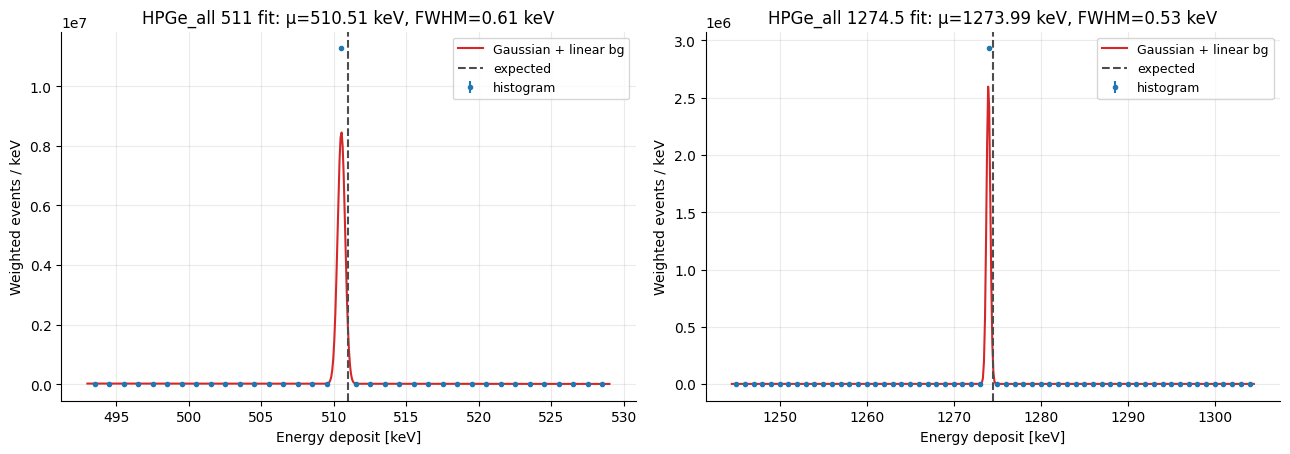

saved output/notebook_figures/hpge_full_energy_peak_fits.png


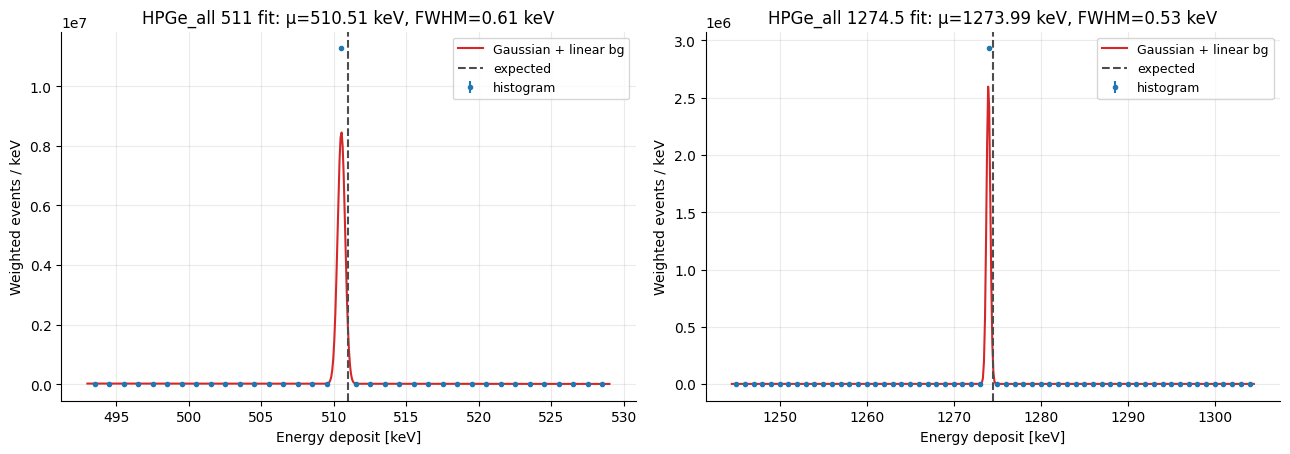

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for ax, fit in zip(axes, [peak_fits[0], peak_fits[1]]):
    if not fit["ok"]:
        ax.text(0.05, 0.8, f"Fit failed: {fit['reason']}", transform=ax.transAxes)
        continue
    counts, edges = np.histogram(hpge_all, bins=fit["bins"], weights=hpge_all_weights)
    variances, _ = np.histogram(
        hpge_all,
        bins=fit["bins"],
        weights=None if hpge_all_weights is None else np.square(hpge_all_weights),
    )
    if hpge_all_weights is None:
        variances = counts
    centers = 0.5 * (edges[:-1] + edges[1:])
    ax.errorbar(centers, counts, yerr=hist_sigma(variances, weighted=hpge_all_weights is not None), fmt="o", ms=3, label="histogram")
    xfine = np.linspace(edges[0], edges[-1], 500)
    ax.plot(xfine, gaussian_linear(xfine, *fit["popt"]), color="tab:red", label="Gaussian + linear bg")
    ax.axvline(fit["expected_keV"], color="0.3", linestyle="--", label="expected")
    ax.set_xlabel("Energy deposit [keV]")
    ax.set_ylabel(f"{COUNT_LABEL} / keV")
    ax.set_title(f"{fit['label']} fit: μ={fit['mu_keV']:.2f} keV, FWHM={fit['fwhm_keV']:.2f} keV")
    ax.legend(fontsize=9)
savefig(fig, "hpge_full_energy_peak_fits.png")

## HPGe Compton Edge Estimates

The expected Compton edges are about 340.7 keV for 511 keV photons and 1061.7 keV for 1274.5 keV photons. The fit is a local smeared step, so treat it as a diagnostic estimate rather than a precision calibration.

label,ok,expected_keV,edge_keV,edge_err_keV,edge_seed_keV,edge_fit_lo_keV,edge_fit_hi_keV,sigma_keV,chi2_ndof
str,bool,f64,f64,f64,f64,f64,f64,f64,f64
"""511 keV Compton edge""",true,340.666667,352.427755,0.033387,341.666667,316.166667,365.166667,18.804037,2250.428119
"""1274.5 keV Compton edge""",true,1061.66683,1090.707504,0.10582,1061.66683,1023.16683,1100.16683,36.539979,923.660081


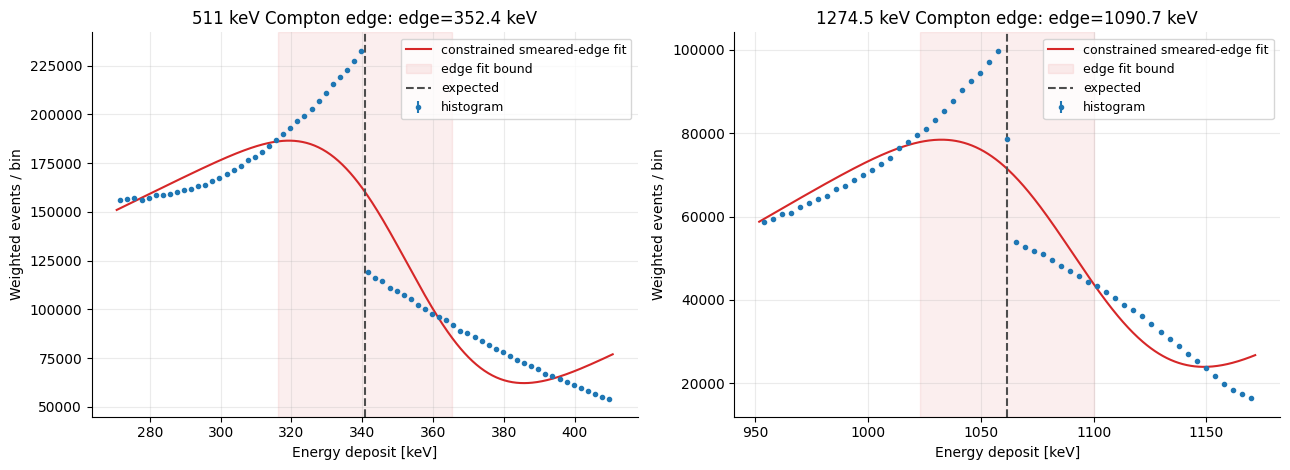

saved output/notebook_figures/hpge_compton_edge_fits.png


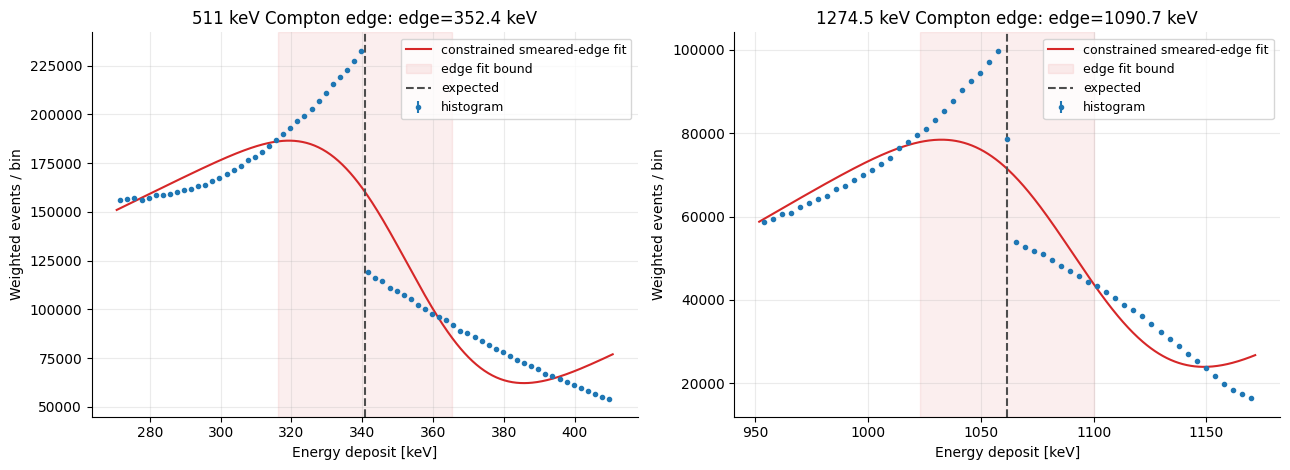

In [65]:
edge_fits = [
    fit_edge(hpge_all, EXPECTED["compton_511_keV"], window=70, bin_width=2, label="511 keV Compton edge", weights=hpge_all_weights),
    fit_edge(hpge_all, EXPECTED["compton_1274_keV"], window=110, bin_width=4, label="1274.5 keV Compton edge", weights=hpge_all_weights),
]
edge_table = pl.DataFrame([
    {k: v for k, v in fit.items() if k not in {"popt", "pcov", "x", "y", "bins", "variances", "smooth_counts", "centers"}}
    for fit in edge_fits
], strict=False)
display(edge_table)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for ax, fit in zip(axes, edge_fits):
    if not fit["ok"]:
        ax.text(0.05, 0.8, f"Fit failed: {fit['reason']}", transform=ax.transAxes)
        continue
    counts, centers, _, variances = hist_counts(hpge_all, bins=fit["bins"], weights=hpge_all_weights, return_variance=True)
    ax.errorbar(centers, counts, yerr=hist_sigma(variances, weighted=hpge_all_weights is not None), fmt="o", ms=3, label="histogram")
    xfine = np.linspace(fit["bins"][0], fit["bins"][-1], 500)
    ax.plot(xfine, smeared_edge(xfine, *fit["popt"]), color="tab:red", label="constrained smeared-edge fit")
    ax.axvspan(fit.get("edge_fit_lo_keV", fit["expected_keV"]), fit.get("edge_fit_hi_keV", fit["expected_keV"]), color="tab:red", alpha=0.08, label="edge fit bound")
    ax.axvline(fit["expected_keV"], color="0.3", linestyle="--", label="expected")
    ax.set_xlabel("Energy deposit [keV]")
    ax.set_ylabel(f"{COUNT_LABEL} / bin")
    ax.set_title(f"{fit['label']}: edge={fit.get('edge_keV', np.nan):.1f} keV")
    ax.legend(fontsize=9)
savefig(fig, "hpge_compton_edge_fits.png")

## Si(Li) Sum Tail / Endpoint Diagnostic

The `22Na` beta-plus endpoint for the branch feeding the 1274.5 keV state is about 545 keV. In this geometry the Si(Li) sum includes backscatter, annihilation photon deposits, and gamma interactions, so this simple linear tail intercept is only a qualitative diagnostic.

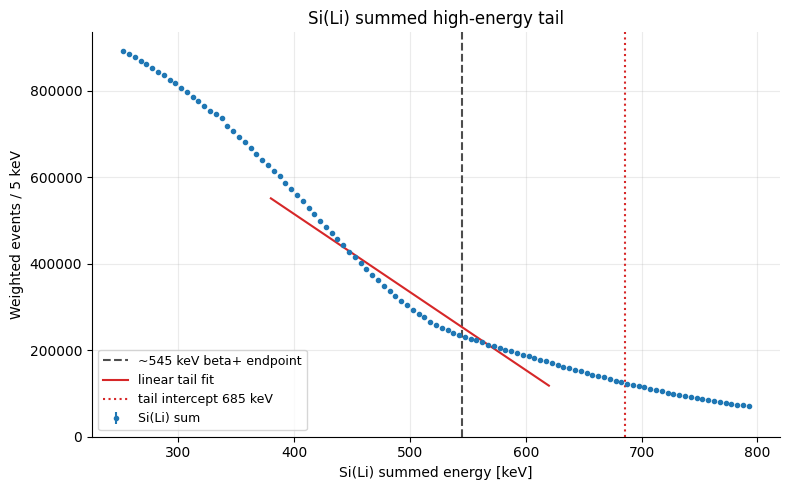

saved output/notebook_figures/sili_sum_tail_endpoint.png


metric,value
str,f64
"""slope""",-1804.391647
"""intercept""",1.2368e6
"""endpoint_keV""",685.433294


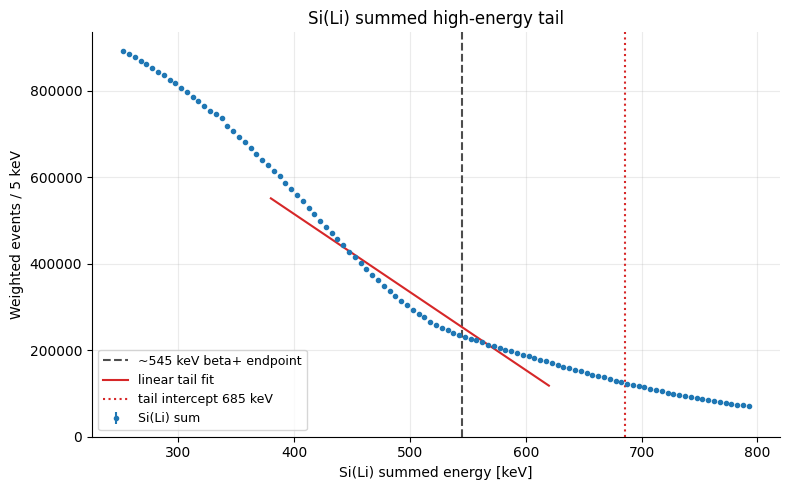

In [66]:
def rough_tail_endpoint(values, weights=None, fit_range=(380, 620), bin_width=5):
    values, fit_weights = finite_positive_with_weights(values, base_weights=weights)
    bins = np.arange(fit_range[0], fit_range[1] + bin_width, bin_width)
    counts, centers, _, variances = hist_counts(values, bins, weights=fit_weights, return_variance=True)
    mask = counts > 0
    if mask.sum() < 5:
        return None
    x = centers[mask]
    y = counts[mask]
    sigma = hist_sigma(variances[mask], weighted=fit_weights is not None)
    coeff, cov = np.polyfit(x, y, deg=1, w=1 / sigma, cov=True)
    slope, intercept = coeff
    endpoint = -intercept / slope if slope != 0 else np.nan
    return {"slope": slope, "intercept": intercept, "endpoint_keV": endpoint, "x": x, "y": y, "bins": bins, "cov": cov}

endpoint_fit = rough_tail_endpoint(silisum, weights=event_weight if HAS_WEIGHTS else None)
fig, ax = plt.subplots(figsize=(8, 5))
zoom_bins = np.arange(250, 800, 5)
counts, centers, _, variances = hist_counts(silisum_pos, zoom_bins, weights=silisum_w, return_variance=True)
ax.errorbar(centers, counts, yerr=hist_sigma(variances, weighted=silisum_w is not None), fmt="o", ms=3, label="Si(Li) sum")
ax.axvline(545, color="0.3", linestyle="--", label="~545 keV beta+ endpoint")
if endpoint_fit:
    xfit = np.linspace(endpoint_fit["bins"][0], endpoint_fit["bins"][-1], 200)
    ax.plot(xfit, endpoint_fit["slope"] * xfit + endpoint_fit["intercept"], color="tab:red", label="linear tail fit")
    ax.axvline(endpoint_fit["endpoint_keV"], color="tab:red", linestyle=":", label=f"tail intercept {endpoint_fit['endpoint_keV']:.0f} keV")
ax.set_xlabel("Si(Li) summed energy [keV]")
ax.set_ylabel(f"{COUNT_LABEL} / 5 keV")
ax.set_ylim(bottom=0)
ax.legend(fontsize=9)
ax.set_title("Si(Li) summed high-energy tail")
savefig(fig, "sili_sum_tail_endpoint.png")

if endpoint_fit:
    display(metrics_frame({k: v for k, v in endpoint_fit.items() if k not in {"x", "y", "bins", "cov"}}))

## Coincidence And Gated Spectra

These gates are deliberately simple and use raw deposited energy. Tight HPGe gates are possible because no detector resolution smearing is applied.

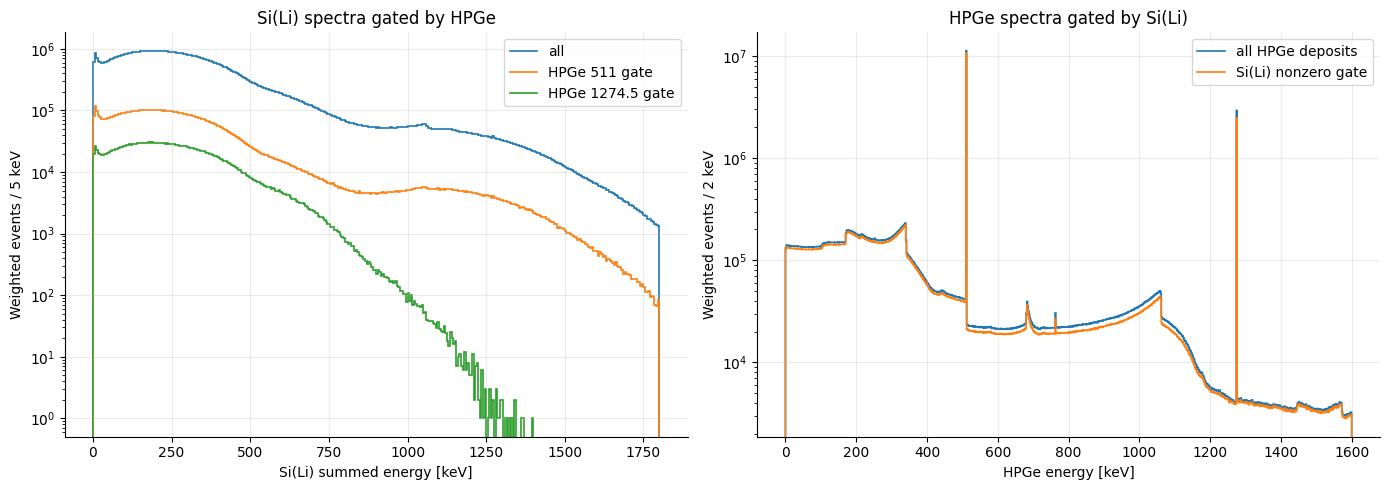

saved output/notebook_figures/coincidence_gated_spectra.png


selection,raw_events,weighted_events
str,i64,f64
"""HPGe max in 511 gate""",9650210,9.65021e6
"""HPGe max in 1274.5 gate""",2955137,2.955137e6
"""Si(Li) hit and HPGe 511 gate""",9156965,9.156965e6
"""Si(Li) hit and HPGe 1274.5 gat…",2506470,2.50647e6


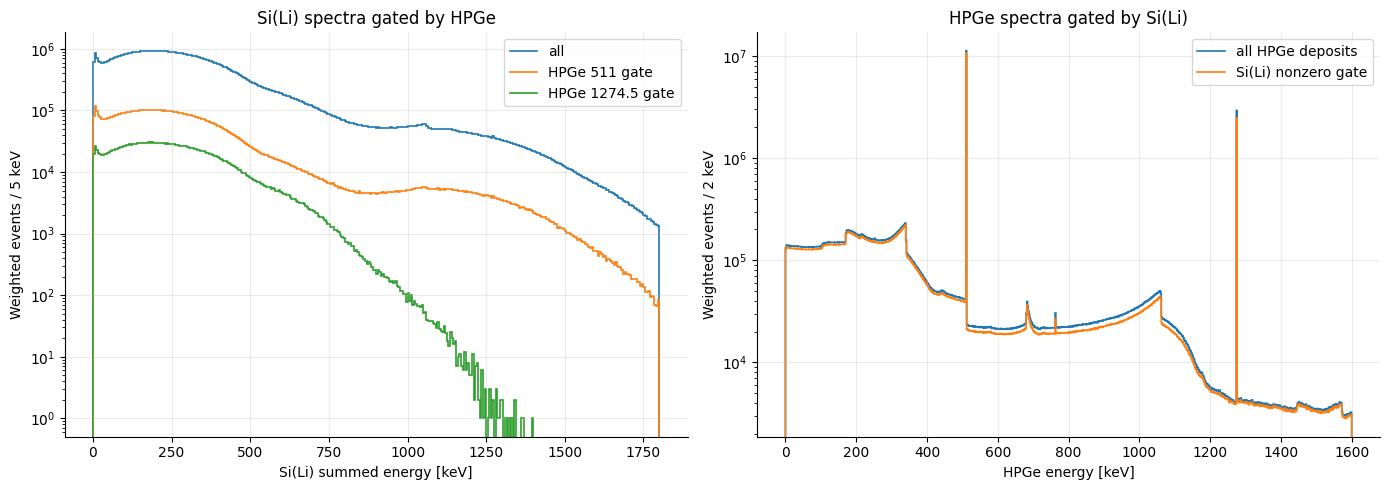

In [67]:
hpge_sum = sum_columns(HPGE_COLUMNS)
hpge_max = max_columns(HPGE_COLUMNS)

hpge_511_gate = (hpge_max > 508) & (hpge_max < 514)
hpge_1274_gate = (hpge_max > 1268) & (hpge_max < 1281)
sili_hit_gate = column_array("E_SiLi_sum_keV") > 0

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
step_hist(axes[0], silisum_pos, bins_sili, weights=silisum_w, label="all", linewidth=1.2)
vals, wts = finite_positive_with_weights(silisum[hpge_511_gate], base_weights=weights_for_mask(hpge_511_gate))
step_hist(axes[0], vals, bins_sili, weights=wts, label="HPGe 511 gate", linewidth=1.2)
vals, wts = finite_positive_with_weights(silisum[hpge_1274_gate], base_weights=weights_for_mask(hpge_1274_gate))
step_hist(axes[0], vals, bins_sili, weights=wts, label="HPGe 1274.5 gate", linewidth=1.2)
axes[0].set_xlabel("Si(Li) summed energy [keV]")
axes[0].set_ylabel(f"{COUNT_LABEL} / 5 keV")
axes[0].set_yscale("log")
axes[0].legend()
axes[0].set_title("Si(Li) spectra gated by HPGe")

step_hist(axes[1], hpge_all, bins_hpge, weights=hpge_all_weights, label="all HPGe deposits", linewidth=1.2)
hpge_sili_values = np.column_stack([hpge[col][sili_hit_gate] for col in HPGE_COLUMNS]).ravel()
hpge_sili_weights = np.repeat(weights_for_mask(sili_hit_gate), len(HPGE_COLUMNS)) if HAS_WEIGHTS else None
vals, wts = finite_positive_with_weights(hpge_sili_values, 0.1, base_weights=hpge_sili_weights)
step_hist(axes[1], vals, bins_hpge, weights=wts, label="Si(Li) nonzero gate", linewidth=1.2)
axes[1].set_xlabel("HPGe energy [keV]")
axes[1].set_ylabel(f"{COUNT_LABEL} / 2 keV")
axes[1].set_yscale("log")
axes[1].legend()
axes[1].set_title("HPGe spectra gated by Si(Li)")
savefig(fig, "coincidence_gated_spectra.png")

coincidence_counts = pl.DataFrame({
    "selection": [
        "HPGe max in 511 gate",
        "HPGe max in 1274.5 gate",
        "Si(Li) hit and HPGe 511 gate",
        "Si(Li) hit and HPGe 1274.5 gate",
    ],
    "raw_events": [
        int(hpge_511_gate.sum()),
        int(hpge_1274_gate.sum()),
        int((sili_hit_gate & hpge_511_gate).sum()),
        int((sili_hit_gate & hpge_1274_gate).sum()),
    ],
    "weighted_events": [
        weighted_count(hpge_511_gate),
        weighted_count(hpge_1274_gate),
        weighted_count(sili_hit_gate & hpge_511_gate),
        weighted_count(sili_hit_gate & hpge_1274_gate),
    ],
})
display(coincidence_counts)

## Back-To-Back 511 keV HPGe Gate

Require the two collinear HPGe detectors (`HPGe_1` on +X and `HPGe_2` on -X) to both be in the 511 keV full-energy window. `HPGe_3` is deliberately ignored here, so the 1274.5 keV gamma is not required.

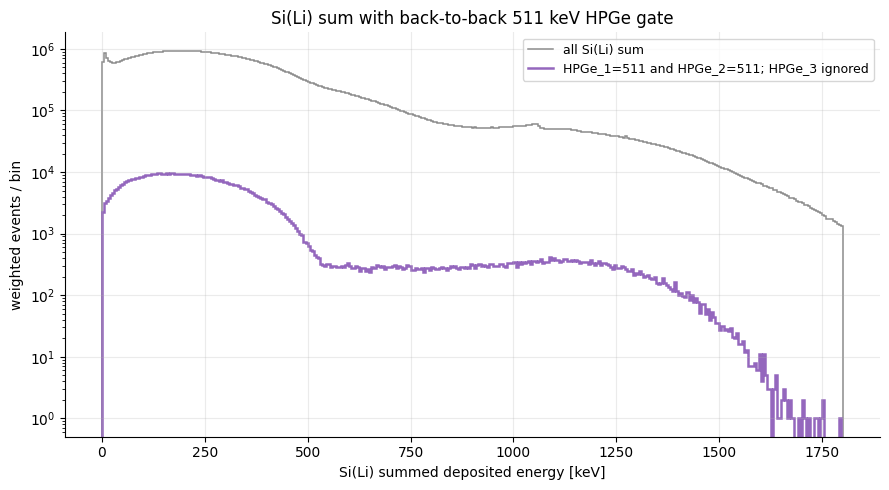

saved output/notebook_figures/sili_sum_back_to_back_511_hpge_gate.png


selection,raw_events,weighted_events
str,i64,f64
"""HPGe_1 511 + HPGe_2 511, HPGe_…",682609,682609.0
"""same gate with nonzero Si(Li) …",669007,669007.0
"""same gate that also has HPGe_3…",8744,8744.0
"""same gate without HPGe_3 in 12…",673865,673865.0


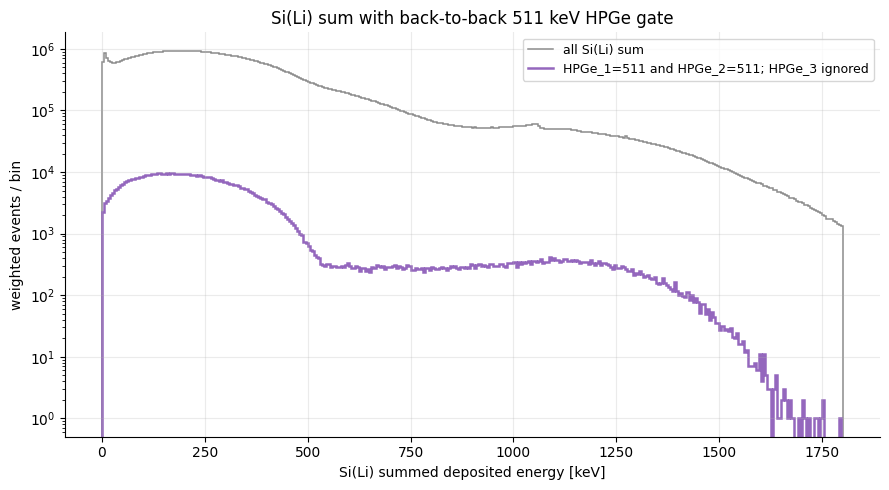

In [68]:
# Back-to-back 511 keV gate: require only the two opposing HPGe detectors.
# No condition is applied to HPGe_3, so the 1274.5 keV gamma is ignored.
E_H1 = column_array("E_HPGe_1_keV")
E_H2 = column_array("E_HPGe_2_keV")
E_H3 = column_array("E_HPGe_3_keV")

WINDOW_511 = (508.0, 514.0)
WINDOW_1274 = (1268.0, 1281.0)

def in_window(values, window):
    lo, hi = window
    return (values >= lo) & (values <= hi)

h1_511 = in_window(E_H1, WINDOW_511)
h2_511 = in_window(E_H2, WINDOW_511)
h3_1274 = in_window(E_H3, WINDOW_1274)
back_to_back_511_gate = h1_511 & h2_511

fig, ax = plt.subplots(figsize=(9, 5))
step_hist(
    ax,
    silisum_pos,
    bins_sili,
    weights=silisum_w,
    label="all Si(Li) sum",
    linewidth=1.1,
    color="0.55",
)
vals, wts = finite_positive_with_weights(
    silisum[back_to_back_511_gate],
    base_weights=weights_for_mask(back_to_back_511_gate),
)
step_hist(
    ax,
    vals,
    bins_sili,
    weights=wts,
    label="HPGe_1=511 and HPGe_2=511; HPGe_3 ignored",
    linewidth=1.8,
    color="tab:purple",
)
ax.set_xlabel("Si(Li) summed deposited energy [keV]")
ax.set_ylabel(BIN_LABEL_SUFFIX)
ax.set_yscale("log")
ax.set_title("Si(Li) sum with back-to-back 511 keV HPGe gate")
ax.legend(fontsize=9)
savefig(fig, "sili_sum_back_to_back_511_hpge_gate.png")

back_to_back_counts = pl.DataFrame({
    "selection": [
        "HPGe_1 511 + HPGe_2 511, HPGe_3 ignored",
        "same gate with nonzero Si(Li) sum",
        "same gate that also has HPGe_3 in 1274.5 keV window",
        "same gate without HPGe_3 in 1274.5 keV window",
    ],
    "raw_events": [
        int(back_to_back_511_gate.sum()),
        int((back_to_back_511_gate & (silisum > 0)).sum()),
        int((back_to_back_511_gate & h3_1274).sum()),
        int((back_to_back_511_gate & ~h3_1274).sum()),
    ],
    "weighted_events": [
        weighted_count(back_to_back_511_gate),
        weighted_count(back_to_back_511_gate & (silisum > 0)),
        weighted_count(back_to_back_511_gate & h3_1274),
        weighted_count(back_to_back_511_gate & ~h3_1274),
    ],
})
display(back_to_back_counts)

## Triple Full-Energy HPGe Tag

Require two HPGe detectors to be in the 511 keV full-energy peak and the remaining detector to be in the 1274.5 keV full-energy peak. This selects events where all three photons are fully tagged, strongly suppressing Compton-tag contamination in the selected Si(Li) summed spectrum.

Two gates are shown:

- **Strict topology:** `HPGe_1` and `HPGe_2` at 511 keV, `HPGe_3` at 1274.5 keV.
- **Any assignment:** any two HPGe detectors at 511 keV and the third at 1274.5 keV.

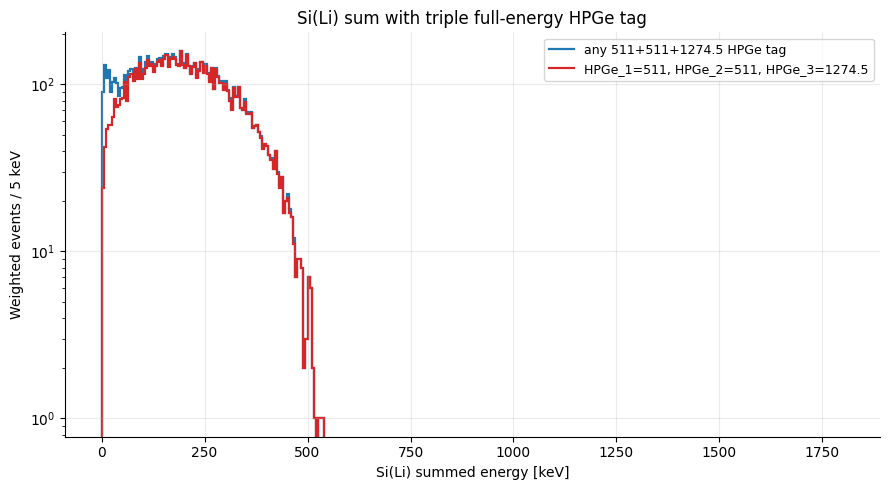

saved output/notebook_figures/sili_sum_triple_hpge_full_energy_tag.png


selection,raw_events,weighted_events
str,i64,f64
"""strict HPGe_1 511 + HPGe_2 511…",8744,8744.0
"""any two HPGe 511 + remaining H…",9801,9801.0
"""strict gate with nonzero Si(Li…",8541,8541.0
"""any-assignment gate with nonze…",9218,9218.0


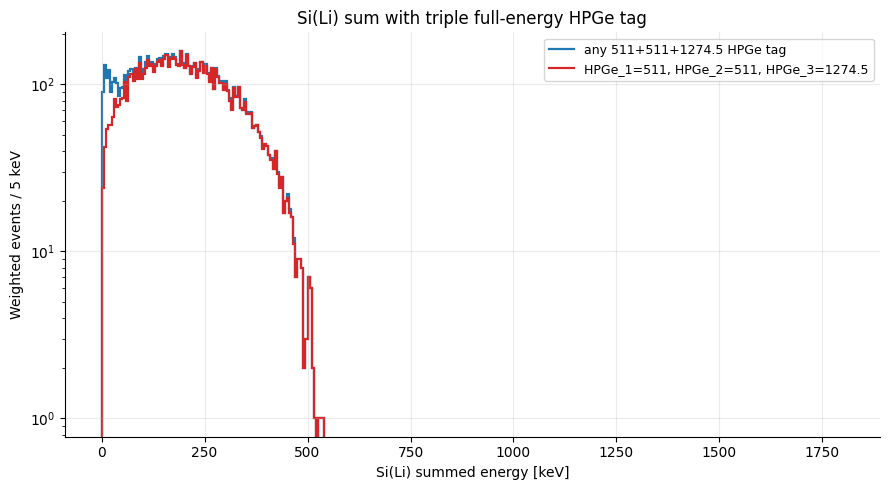

In [69]:
# Triple full-energy HPGe tag: two 511 keV photons plus the 1274.5 keV gamma.
# The windows are intentionally tight because the simulation output is unsmeared.
E_H1 = column_array("E_HPGe_1_keV")
E_H2 = column_array("E_HPGe_2_keV")
E_H3 = column_array("E_HPGe_3_keV")

WINDOW_511 = (508.0, 514.0)
WINDOW_1274 = (1268.0, 1281.0)

def in_window(values, window):
    lo, hi = window
    return (values >= lo) & (values <= hi)

h1_511 = in_window(E_H1, WINDOW_511)
h2_511 = in_window(E_H2, WINDOW_511)
h3_511 = in_window(E_H3, WINDOW_511)
h1_1274 = in_window(E_H1, WINDOW_1274)
h2_1274 = in_window(E_H2, WINDOW_1274)
h3_1274 = in_window(E_H3, WINDOW_1274)


strict_511_511_1274_gate = h1_511 & h2_511 & h3_1274
any_511_511_1274_gate = (
    (h1_511 & h2_511 & h3_1274) |
    (h1_511 & h3_511 & h2_1274) |
    (h2_511 & h3_511 & h1_1274)
)

fig, ax = plt.subplots(figsize=(9, 5))
vals, wts = finite_positive_with_weights(silisum[any_511_511_1274_gate], base_weights=weights_for_mask(any_511_511_1274_gate))
step_hist(
    ax,
    vals,
    bins_sili,
    weights=wts,
    label="any 511+511+1274.5 HPGe tag",
    linewidth=1.6,
    color="tab:blue",
)
vals, wts = finite_positive_with_weights(silisum[strict_511_511_1274_gate], base_weights=weights_for_mask(strict_511_511_1274_gate))
step_hist(
    ax,
    vals,
    bins_sili,
    weights=wts,
    label="HPGe_1=511, HPGe_2=511, HPGe_3=1274.5",
    linewidth=1.6,
    color="tab:red",
)
ax.set_xlabel("Si(Li) summed energy [keV]")
ax.set_ylabel(f"{COUNT_LABEL} / 5 keV")
ax.set_yscale("log")
ax.legend(fontsize=9)
ax.set_title("Si(Li) sum with triple full-energy HPGe tag")
savefig(fig, "sili_sum_triple_hpge_full_energy_tag.png")

triple_gate_summary = pl.DataFrame({
    "selection": [
        "strict HPGe_1 511 + HPGe_2 511 + HPGe_3 1274.5",
        "any two HPGe 511 + remaining HPGe 1274.5",
        "strict gate with nonzero Si(Li) sum",
        "any-assignment gate with nonzero Si(Li) sum",
    ],
    "raw_events": [
        int(strict_511_511_1274_gate.sum()),
        int(any_511_511_1274_gate.sum()),
        int((strict_511_511_1274_gate & (silisum > 0)).sum()),
        int((any_511_511_1274_gate & (silisum > 0)).sum()),
    ],
    "weighted_events": [
        weighted_count(strict_511_511_1274_gate),
        weighted_count(any_511_511_1274_gate),
        weighted_count(strict_511_511_1274_gate & (silisum > 0)),
        weighted_count(any_511_511_1274_gate & (silisum > 0)),
    ],
})
display(triple_gate_summary)

if any_511_511_1274_gate.sum() == 0:
    print("No triple full-energy-tagged events in this sample. This is expected for small runs; use the production or importance-sampled file for this gate.")

## Triple-Gated 22Na Beta-Plus Spectrum Fit

Fit the summed Si(Li) spectrum under the triple full-energy HPGe tag to a simple allowed beta-plus phase-space shape. This fit is intended as a spectrum-shape diagnostic; it does not include a Fermi function, detector response convolution, or detailed Si(Li) acceptance correction.

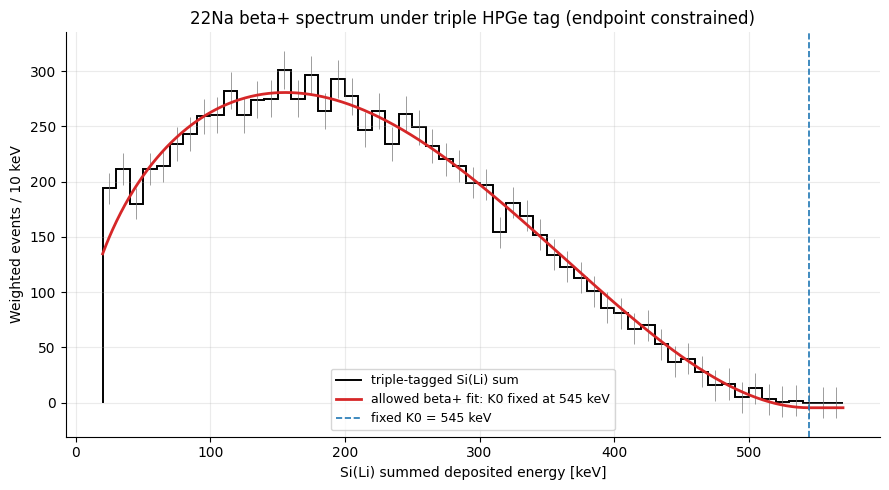

saved output/notebook_figures/sili_sum_triple_hpge_22na_beta_fit.png


metric,value
str,f64
"""fit_min_keV""",20.0
"""fit_max_keV""",570.0
"""endpoint_fixed""",1.0
"""endpoint_keV""",545.0
"""norm""",285.046426
"""norm_err""",6.104124
"""background_counts_per_bin""",-4.489267
"""chi2_ndof""",0.738092
"""n_events_in_fit_range""",8766.0


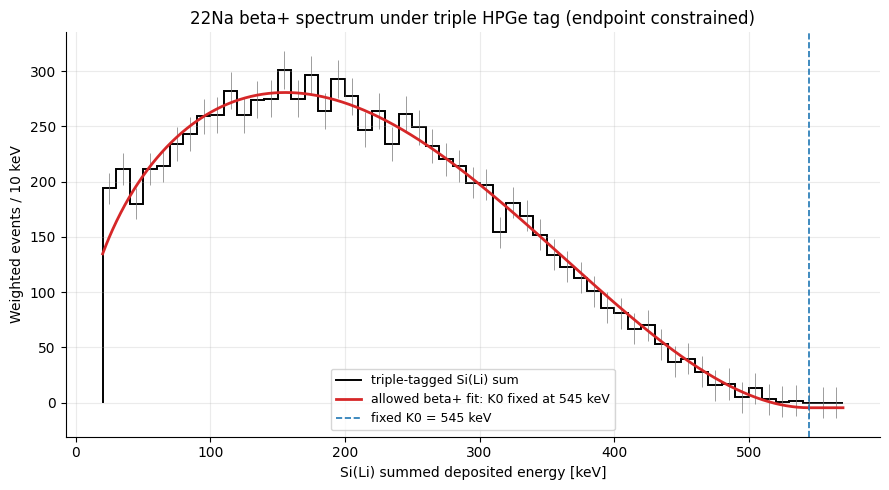

In [75]:
# 22Na beta-plus spectrum fit under the triple full-energy HPGe tag.
# The physical endpoint is fixed to the known 22Na beta+ endpoint. The fit floats
# only normalization and a flat background over the selected fit range.
BETA_PLUS_ENDPOINT_22NA_KEV = 545.0
ELECTRON_MASS_KEV = 510.99895
SMOOTH_FIT_POINTS = 900


def beta_plus_allowed_shape(kinetic_keV, endpoint_keV=BETA_PLUS_ENDPOINT_22NA_KEV):
    kinetic_keV = np.asarray(kinetic_keV, dtype=float)
    shape = np.zeros_like(kinetic_keV, dtype=float)
    mask = (kinetic_keV > 0.0) & (kinetic_keV < endpoint_keV)
    if not np.any(mask):
        return shape
    k = kinetic_keV[mask]
    momentum_keV = np.sqrt(k * (k + 2.0 * ELECTRON_MASS_KEV))
    total_energy_keV = k + ELECTRON_MASS_KEV
    shape[mask] = momentum_keV * total_energy_keV * (endpoint_keV - k) ** 2
    max_shape = np.nanmax(shape)
    return shape / max_shape if max_shape > 0 else shape


def beta_plus_fit_model(kinetic_keV, norm, background):
    return norm * beta_plus_allowed_shape(kinetic_keV, BETA_PLUS_ENDPOINT_22NA_KEV) + background


def fit_na22_beta_spectrum(values, label, weights=None, fit_range=(20.0, 570.0), bin_width=10.0):
    values = np.asarray(values, dtype=float)
    if weights is None:
        base_weights = None
        valid = np.isfinite(values) & (values > 0.1)
    else:
        base_weights = np.asarray(weights, dtype=float)
        valid = np.isfinite(values) & (values > 0.1) & np.isfinite(base_weights) & (base_weights > 0)
        base_weights = base_weights[valid]
    values = values[valid]

    lo, hi = fit_range
    bins = np.arange(lo, hi + bin_width, bin_width)
    counts, centers, widths, variances = hist_counts(values, bins, weights=base_weights, return_variance=True)
    fit_mask = counts > 0

    if counts.sum() < 100 or np.count_nonzero(fit_mask) < 12:
        return {
            "label": label,
            "ok": False,
            "reason": "too few counts for beta spectrum fit",
            "counts": counts,
            "variances": variances,
            "centers": centers,
            "bins": bins,
            "endpoint_fixed": True,
            "endpoint_keV": BETA_PLUS_ENDPOINT_22NA_KEV,
            "use_template": False,
        }

    x = centers[fit_mask]
    y = counts[fit_mask]
    sigma_y = hist_sigma(variances[fit_mask], weighted=base_weights is not None)

    p0 = [max(y.max(), 1.0), 0.0]
    bounds = ([0.0, -20.0], [np.inf, np.inf])
    try:
        popt, pcov = curve_fit(
            beta_plus_fit_model,
            x,
            y,
            p0=p0,
            sigma=sigma_y,
            absolute_sigma=True,
            bounds=bounds,
            maxfev=50000,
        )
        perr = np.sqrt(np.diag(pcov))
    except Exception as exc:
        return {
            "label": label,
            "ok": False,
            "reason": str(exc),
            "counts": counts,
            "variances": variances,
            "centers": centers,
            "bins": bins,
            "endpoint_fixed": True,
            "endpoint_keV": BETA_PLUS_ENDPOINT_22NA_KEV,
            "use_template": False,
        }

    model_y = beta_plus_fit_model(x, *popt)
    residual = (y - model_y) / sigma_y
    chi2 = float(np.sum(residual ** 2))
    ndof = int(len(y) - len(popt))
    smooth_x = np.linspace(bins[0], bins[-1], SMOOTH_FIT_POINTS)
    smooth_y = beta_plus_fit_model(smooth_x, *popt)

    return {
        "label": label,
        "ok": True,
        "norm": popt[0],
        "norm_err": perr[0],
        "endpoint_fixed": True,
        "endpoint_keV": BETA_PLUS_ENDPOINT_22NA_KEV,
        "endpoint_err_keV": 0.0,
        "background_counts_per_bin": popt[1],
        "background_err_counts_per_bin": perr[1],
        "chi2": chi2,
        "ndof": ndof,
        "chi2_ndof": chi2 / ndof if ndof > 0 else np.nan,
        "n_events_in_fit_range": float(counts.sum()),
        "fit_min_keV": lo,
        "fit_max_keV": hi,
        "use_template": False,
        "popt": popt,
        "pcov": pcov,
        "counts": counts,
        "variances": variances,
        "model_counts": beta_plus_fit_model(centers, *popt),
        "model_smooth_x": smooth_x,
        "model_smooth_y": smooth_y,
        "centers": centers,
        "bins": bins,
        "fit_mask": fit_mask,
    }


triple_gate_mask = any_511_511_1274_gate
triple_beta_values = silisum[triple_gate_mask]
triple_beta_weights = weights_for_mask(triple_gate_mask)
triple_beta_fit = fit_na22_beta_spectrum(
    triple_beta_values,
    weights=triple_beta_weights,
    label="any 511+511+1274.5 HPGe tag",
)

fig, ax = plt.subplots(figsize=(9, 5))
counts = triple_beta_fit["counts"]
variances = triple_beta_fit["variances"]
bins = triple_beta_fit["bins"]
centers = triple_beta_fit["centers"]
ax.stairs(counts, bins, label="triple-tagged Si(Li) sum", linewidth=1.4, color="black")
ax.errorbar(
    centers,
    counts,
    yerr=hist_sigma(variances, weighted=triple_beta_weights is not None),
    fmt="none",
    ecolor="0.45",
    elinewidth=0.7,
    alpha=0.7,
)

if triple_beta_fit["ok"]:
    ax.plot(
        triple_beta_fit["model_smooth_x"],
        triple_beta_fit["model_smooth_y"],
        color="tab:red",
        linewidth=2.0,
        label=f"allowed beta+ fit: K0 fixed at {BETA_PLUS_ENDPOINT_22NA_KEV:.0f} keV",
    )
else:
    ax.text(0.04, 0.92, triple_beta_fit["reason"], transform=ax.transAxes, color="tab:red")

ax.axvline(BETA_PLUS_ENDPOINT_22NA_KEV, color="tab:blue", linestyle="--", linewidth=1.2, label="fixed K0 = 545 keV")
ax.set_xlabel("Si(Li) summed deposited energy [keV]")
ax.set_ylabel(f"{COUNT_LABEL} / 10 keV")
ax.set_title("22Na beta+ spectrum under triple HPGe tag (endpoint constrained)")
ax.legend(fontsize=9)
savefig(fig, "sili_sum_triple_hpge_22na_beta_fit.png")

fit_summary_keys = [
    "fit_min_keV",
    "fit_max_keV",
    "endpoint_fixed",
    "endpoint_keV",
    "norm",
    "norm_err",
    "background_counts_per_bin",
    "chi2_ndof",
    "n_events_in_fit_range",
]
fit_summary = metrics_frame({k: triple_beta_fit.get(k, np.nan) for k in fit_summary_keys})
display(fit_summary)

## Triple-Gated Fierz-Term Constraint

Add a Fierz interference term to the allowed beta-plus spectrum, multiplying the shape by `1 + b m_e / E`. The endpoint is fixed to the nominal `22Na` beta-plus endpoint for the interval extraction; normalization and constant background are profiled as nuisance parameters. These are statistical bounds for this simplified spectrum model, not final experimental limits.

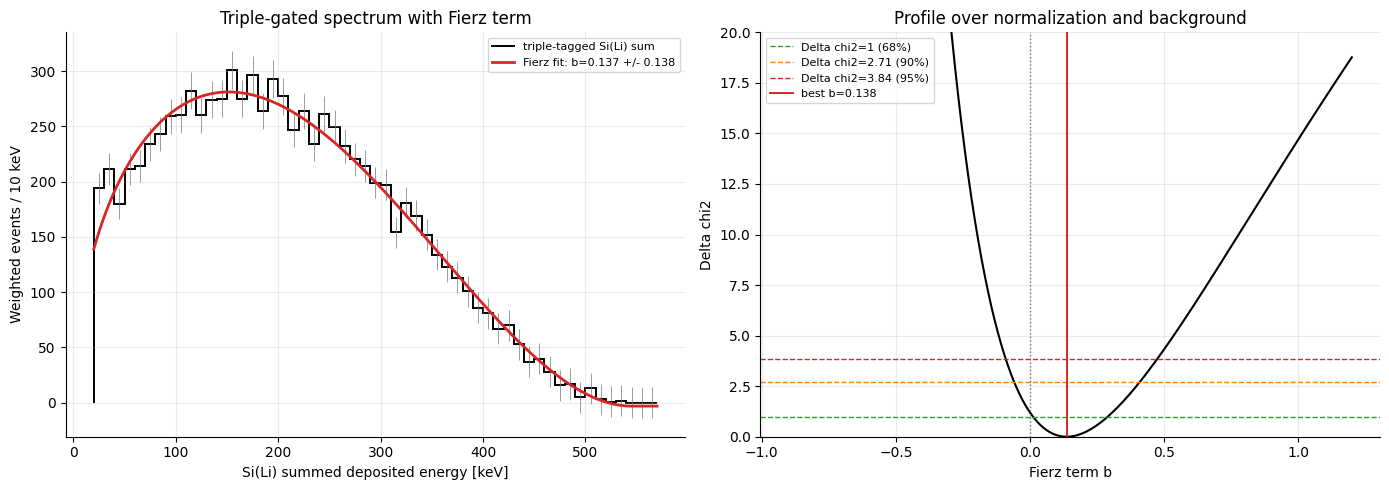

saved output/notebook_figures/sili_sum_triple_hpge_fierz_fit.png


metric,value
str,f64
"""b_direct_fit""",0.136889
"""b_direct_fit_err_covariance""",0.138389
"""b_profile_best""",0.1375
"""b_68_lower""",0.011023
"""b_68_upper""",0.290635
…,…
"""b_95_lower""",-0.090153
"""b_95_upper""",0.474261
"""endpoint_fixed_keV""",545.0


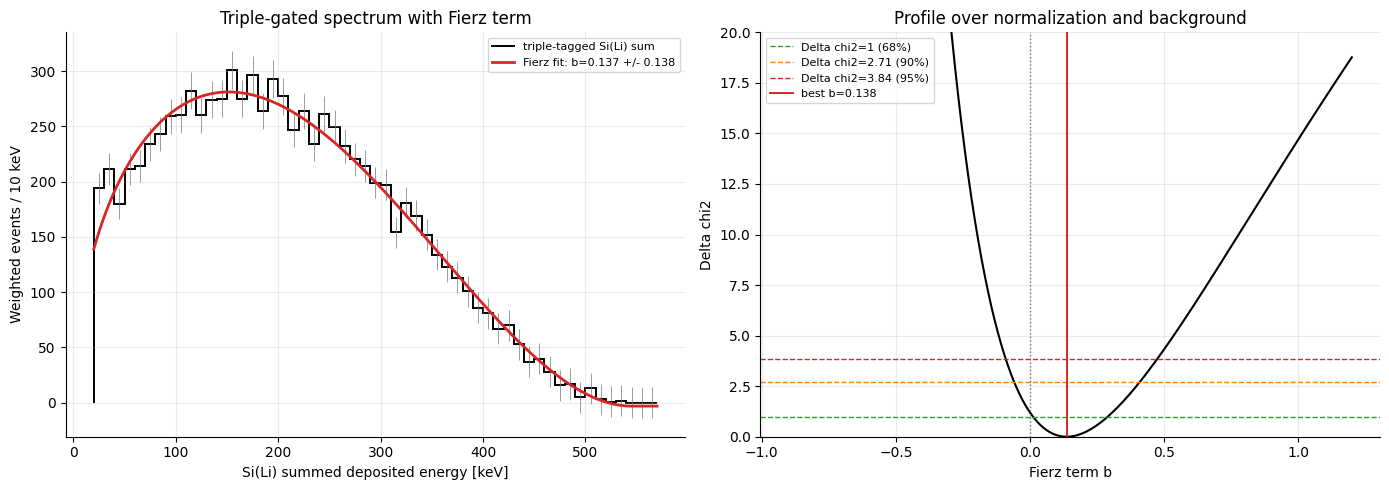

In [76]:
# Fierz-term fit and profile-likelihood-style bounds.
# This uses the same normal smooth spectrum model as the endpoint fit, with the
# endpoint fixed and the Fierz term floated.
FIERZ_PROFILE_RANGE = (-0.90, 1.20)
FIERZ_PROFILE_POINTS = 841


def beta_plus_fierz_shape(kinetic_keV, endpoint_keV, fierz_b):
    kinetic_keV = np.asarray(kinetic_keV, dtype=float)
    shape = np.zeros_like(kinetic_keV, dtype=float)
    mask = (kinetic_keV > 0.0) & (kinetic_keV < endpoint_keV)
    if not np.any(mask):
        return shape
    k = kinetic_keV[mask]
    momentum_keV = np.sqrt(k * (k + 2.0 * ELECTRON_MASS_KEV))
    total_energy_keV = k + ELECTRON_MASS_KEV
    fierz_factor = 1.0 + fierz_b * ELECTRON_MASS_KEV / total_energy_keV
    shape[mask] = momentum_keV * total_energy_keV * (endpoint_keV - k) ** 2 * fierz_factor
    if np.any(shape[mask] < 0.0):
        return np.full_like(shape, np.nan)
    max_shape = np.nanmax(shape)
    return shape / max_shape if max_shape > 0 else shape


def beta_plus_fierz_model(kinetic_keV, norm, fierz_b, background):
    return norm * beta_plus_fierz_shape(
        kinetic_keV, BETA_PLUS_ENDPOINT_22NA_KEV, fierz_b
    ) + background


def fit_fierz_direct(centers, counts, variances):
    mask = counts > 0
    x = centers[mask]
    y = counts[mask]
    sigma_y = hist_sigma(variances[mask], weighted=HAS_WEIGHTS)
    p0 = [max(y.max(), 1.0), 0.0, 0.0]
    bounds = ([0.0, FIERZ_PROFILE_RANGE[0], -20.0], [np.inf, FIERZ_PROFILE_RANGE[1], np.inf])
    popt, pcov = curve_fit(
        beta_plus_fierz_model,
        x,
        y,
        p0=p0,
        sigma=sigma_y,
        absolute_sigma=True,
        bounds=bounds,
        maxfev=50000,
    )
    residual = (y - beta_plus_fierz_model(x, *popt)) / sigma_y
    chi2 = float(np.sum(residual ** 2))
    return popt, pcov, chi2, len(y) - len(popt)


def profile_fierz_b(centers, counts, variances, b_values):
    mask = counts > 0
    x = centers[mask]
    y = counts[mask]
    sigma_y = hist_sigma(variances[mask], weighted=HAS_WEIGHTS)
    chi2_values = []
    nuisance_values = []

    for b_value in b_values:
        shape = beta_plus_fierz_shape(x, BETA_PLUS_ENDPOINT_22NA_KEV, b_value)
        if not np.all(np.isfinite(shape)):
            chi2_values.append(np.inf)
            nuisance_values.append((np.nan, np.nan))
            continue

        def fixed_b_model(energy, norm, background):
            return norm * beta_plus_fierz_shape(
                energy, BETA_PLUS_ENDPOINT_22NA_KEV, b_value
            ) + background

        try:
            popt, _ = curve_fit(
                fixed_b_model,
                x,
                y,
                p0=[max(y.max(), 1.0), 0.0],
                sigma=sigma_y,
                absolute_sigma=True,
                bounds=([0.0, -20.0], [np.inf, np.inf]),
                maxfev=20000,
            )
            residual = (y - fixed_b_model(x, *popt)) / sigma_y
            chi2_values.append(float(np.sum(residual ** 2)))
            nuisance_values.append(tuple(popt))
        except Exception:
            chi2_values.append(np.inf)
            nuisance_values.append((np.nan, np.nan))

    return np.asarray(chi2_values), np.asarray(nuisance_values)


def profile_interval(x, y, delta):
    finite = np.isfinite(y)
    x = np.asarray(x)[finite]
    y = np.asarray(y)[finite]
    if len(x) < 3:
        return (np.nan, np.nan)
    best_index = int(np.argmin(y))
    target = y[best_index] + delta

    lower = np.nan
    for i in range(best_index, 0, -1):
        if (y[i] - target) * (y[i - 1] - target) <= 0:
            lower = np.interp(target, [y[i], y[i - 1]], [x[i], x[i - 1]])
            break

    upper = np.nan
    for i in range(best_index, len(x) - 1):
        if (y[i] - target) * (y[i + 1] - target) <= 0:
            upper = np.interp(target, [y[i], y[i + 1]], [x[i], x[i + 1]])
            break

    return lower, upper


fierz_counts = triple_beta_fit["counts"]
fierz_variances = triple_beta_fit["variances"]
fierz_centers = triple_beta_fit["centers"]
fierz_bins = triple_beta_fit["bins"]

if not triple_beta_fit["ok"] or np.count_nonzero(fierz_counts > 0) < 6:
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.text(
        0.05,
        0.75,
        "Fierz fit skipped: too few weighted triple-gated counts",
        transform=ax.transAxes,
        color="tab:red",
    )
    ax.set_axis_off()
    savefig(fig, "sili_sum_triple_hpge_fierz_fit.png")
    fierz_summary = metrics_frame({
        "ok": False,
        "reason": triple_beta_fit.get("reason", "too few weighted triple-gated counts"),
        "weighted_events_in_fit_range": float(np.sum(fierz_counts)),
        "nonzero_bins": int(np.count_nonzero(fierz_counts > 0)),
    })
    display(fierz_summary)
else:
    fierz_popt, fierz_pcov, fierz_chi2, fierz_ndof = fit_fierz_direct(fierz_centers, fierz_counts, fierz_variances)
    fierz_perr = np.sqrt(np.diag(fierz_pcov))
    b_grid = np.linspace(*FIERZ_PROFILE_RANGE, FIERZ_PROFILE_POINTS)
    profile_chi2, profile_nuisance = profile_fierz_b(fierz_centers, fierz_counts, fierz_variances, b_grid)
    best_profile_index = int(np.nanargmin(profile_chi2))
    b_best_profile = b_grid[best_profile_index]
    chi2_min_profile = profile_chi2[best_profile_index]
    profile_delta = profile_chi2 - chi2_min_profile

    b_68 = profile_interval(b_grid, profile_chi2, 1.00)
    b_90 = profile_interval(b_grid, profile_chi2, 2.71)
    b_95 = profile_interval(b_grid, profile_chi2, 3.84)

    xfit = np.linspace(fierz_bins[0], fierz_bins[-1], SMOOTH_FIT_POINTS)
    yfit = beta_plus_fierz_model(xfit, *fierz_popt)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].stairs(fierz_counts, fierz_bins, label="triple-tagged Si(Li) sum", linewidth=1.4, color="black")
    axes[0].errorbar(
        fierz_centers,
        fierz_counts,
        yerr=hist_sigma(fierz_variances, weighted=HAS_WEIGHTS),
        fmt="none",
        ecolor="0.45",
        elinewidth=0.7,
        alpha=0.7,
    )
    axes[0].plot(
        xfit,
        yfit,
        color="tab:red",
        linewidth=2.0,
        label=f"Fierz fit: b={fierz_popt[1]:.3f} +/- {fierz_perr[1]:.3f}",
    )
    axes[0].set_xlabel("Si(Li) summed deposited energy [keV]")
    axes[0].set_ylabel(f"{COUNT_LABEL} / 10 keV")
    axes[0].set_title("Triple-gated spectrum with Fierz term")
    axes[0].legend(fontsize=8)

    axes[1].plot(b_grid, profile_delta, color="black", linewidth=1.5)
    for delta, label, color in [(1.00, "68%", "tab:green"), (2.71, "90%", "tab:orange"), (3.84, "95%", "tab:red")]:
        axes[1].axhline(delta, color=color, linestyle="--", linewidth=1.0, label=f"Delta chi2={delta:g} ({label})")
    axes[1].axvline(b_best_profile, color="tab:red", linewidth=1.4, label=f"best b={b_best_profile:.3f}")
    axes[1].axvline(0.0, color="0.45", linestyle=":", linewidth=1.0)
    axes[1].set_xlabel("Fierz term b")
    axes[1].set_ylabel("Delta chi2")
    axes[1].set_ylim(bottom=0.0, top=max(6.0, np.nanmin([np.nanmax(profile_delta), 20.0])))
    axes[1].set_title("Profile over normalization and background")
    axes[1].legend(fontsize=8)
    savefig(fig, "sili_sum_triple_hpge_fierz_fit.png")

    fierz_summary = metrics_frame({
        "b_direct_fit": fierz_popt[1],
        "b_direct_fit_err_covariance": fierz_perr[1],
        "b_profile_best": b_best_profile,
        "b_68_lower": b_68[0],
        "b_68_upper": b_68[1],
        "b_90_lower": b_90[0],
        "b_90_upper": b_90[1],
        "b_95_lower": b_95[0],
        "b_95_upper": b_95[1],
        "endpoint_fixed_keV": BETA_PLUS_ENDPOINT_22NA_KEV,
        "chi2_ndof_direct_fit": fierz_chi2 / fierz_ndof,
        "chi2_ndof_profile_best": chi2_min_profile / (np.count_nonzero(fierz_counts > 0) - 2),
    })
    display(fierz_summary)

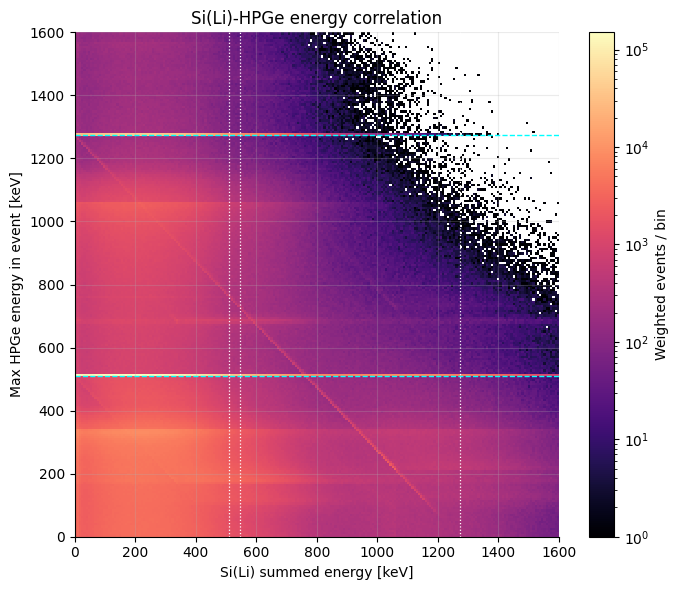

saved output/notebook_figures/sili_hpge_correlation.png


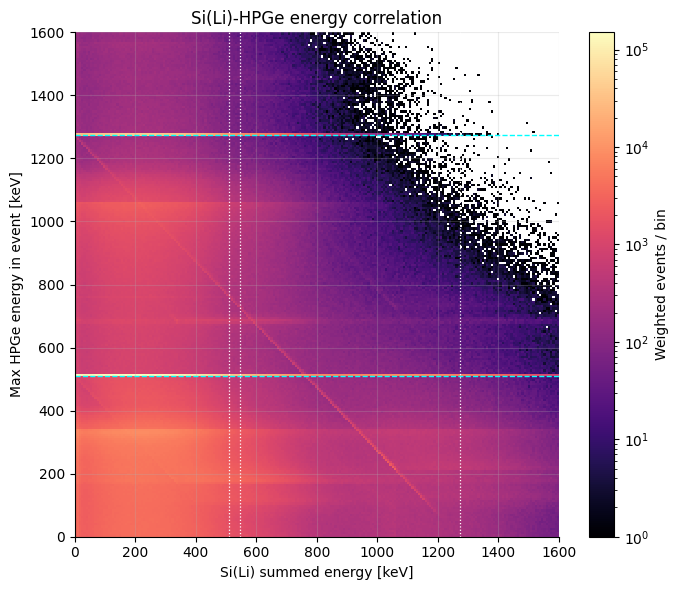

In [72]:
from matplotlib.colors import LogNorm

mask = (
    np.isfinite(silisum)
    & np.isfinite(hpge_max)
    & (silisum > 0.1)
    & (hpge_max > 0.1)
)

fig, ax = plt.subplots(figsize=(7, 6))
h = ax.hist2d(
    silisum[mask],
    hpge_max[mask],
    bins=[220, 220],
    range=[[0, 1600], [0, 1600]],
    weights=weights_for_mask(mask),
    cmap="magma",
    norm=LogNorm(),
    cmin=None if HAS_WEIGHTS else 1,
)
fig.colorbar(h[3], ax=ax, label=f"{COUNT_LABEL} / bin")

for energy in [EXPECTED["annihilation_keV"], EXPECTED["na22_gamma_keV"]]:
    ax.axhline(energy, color="cyan", linestyle="--", linewidth=1)

for energy in [545, EXPECTED["annihilation_keV"], EXPECTED["na22_gamma_keV"]]:
    ax.axvline(energy, color="white", linestyle=":", linewidth=0.9)

ax.set_xlabel("Si(Li) summed energy [keV]")
ax.set_ylabel("Max HPGe energy in event [keV]")
ax.set_title("Si(Li)-HPGe energy correlation")
savefig(fig, "sili_hpge_correlation.png")

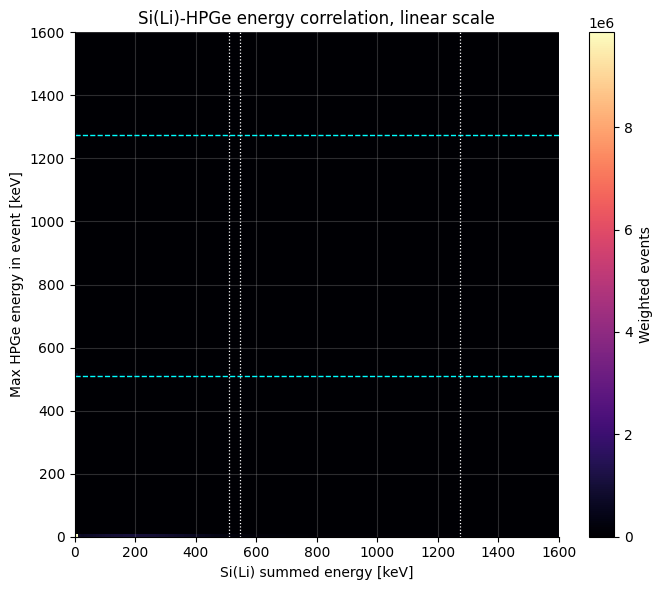

saved output/notebook_figures/sili_hpge_correlation_linear.png


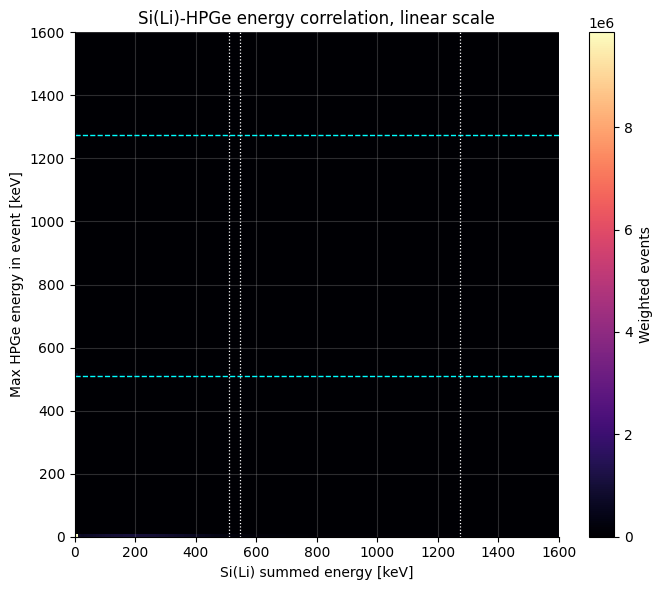

In [73]:
fig, ax = plt.subplots(figsize=(7, 6))
h = ax.hist2d(
    silisum,
    hpge_max,
    bins=[160, 160],
    range=[[0, 1600], [0, 1600]],
    weights=event_weight if HAS_WEIGHTS else None,
    cmap="magma",
)
fig.colorbar(h[3], ax=ax, label=COUNT_LABEL)
for energy in [EXPECTED["annihilation_keV"], EXPECTED["na22_gamma_keV"]]:
    ax.axhline(energy, color="cyan", linestyle="--", linewidth=1)
for energy in [545, EXPECTED["annihilation_keV"], EXPECTED["na22_gamma_keV"]]:
    ax.axvline(energy, color="white", linestyle=":", linewidth=0.9)
ax.set_xlabel("Si(Li) summed energy [keV]")
ax.set_ylabel("Max HPGe energy in event [keV]")
ax.set_title("Si(Li)-HPGe energy correlation, linear scale")
savefig(fig, "sili_hpge_correlation_linear.png")

## Fit Summary

The tables below collect successful peak and edge fits for quick inspection.

In [74]:
peak_summary = fit_table.filter(pl.col("ok") == True)
edge_summary = edge_table.filter(pl.col("ok") == True)
cols_peak = ["label", "expected_keV", "mu_keV", "mu_err_keV", "sigma_keV", "fwhm_keV", "area_counts"]
cols_edge = ["label", "expected_keV", "edge_keV", "edge_err_keV", "sigma_keV"]
print("Successful peak fits")
peak_cols_present = [c for c in cols_peak if c in peak_summary.columns]
display(peak_summary.select(peak_cols_present) if peak_cols_present else peak_summary)
print("Successful Compton edge fits")
edge_cols_present = [c for c in cols_edge if c in edge_summary.columns]
display(edge_summary.select(edge_cols_present) if edge_cols_present else edge_summary)

Successful peak fits


label,expected_keV,mu_keV,mu_err_keV,sigma_keV,fwhm_keV,area_counts
str,f64,f64,f64,f64,f64,f64
"""HPGe_all 511""",511.0,510.514144,0.001288,0.260425,0.613254,5.5158e6
"""HPGe_all 1274.5""",1274.5,1273.98942,0.013203,0.224619,0.528937,1.4741e6
"""HPGe_1_keV 511""",511.0,510.496981,0.002148,0.260007,0.61227,1.8385e6
"""HPGe_1_keV 1274.5""",1274.5,1274.001408,0.023184,0.223842,0.527107,495059.796141
"""HPGe_2_keV 511""",511.0,510.49632,0.00212,0.260278,0.612908,1.8422e6
"""HPGe_2_keV 1274.5""",1274.5,1274.001651,0.022716,0.224103,0.527723,496005.676392
"""HPGe_3_keV 511""",511.0,510.497054,0.002095,0.260219,0.612768,1.8643e6
"""HPGe_3_keV 1274.5""",1274.5,1273.999519,0.008625,0.237908,0.56023,519176.197608


Successful Compton edge fits


label,expected_keV,edge_keV,edge_err_keV,sigma_keV
str,f64,f64,f64,f64
"""511 keV Compton edge""",340.666667,352.427755,0.033387,18.804037
"""1274.5 keV Compton edge""",1061.66683,1090.707504,0.10582,36.539979


## Notes And Next Steps

- The HPGe peak centroids should sit close to 511 and 1274.5 keV in this unsmeared simulation.
- Si(Li) symmetry should improve with larger event counts.
- The Si(Li) summed spectrum is the key spectrum for backscatter recovery studies.
- Future refinements: add detector resolution smearing, use larger statistics for edge fits, and add truth-level columns by running with `/output/truthOutput true`.